# Caso compensado vs caso sin compensación

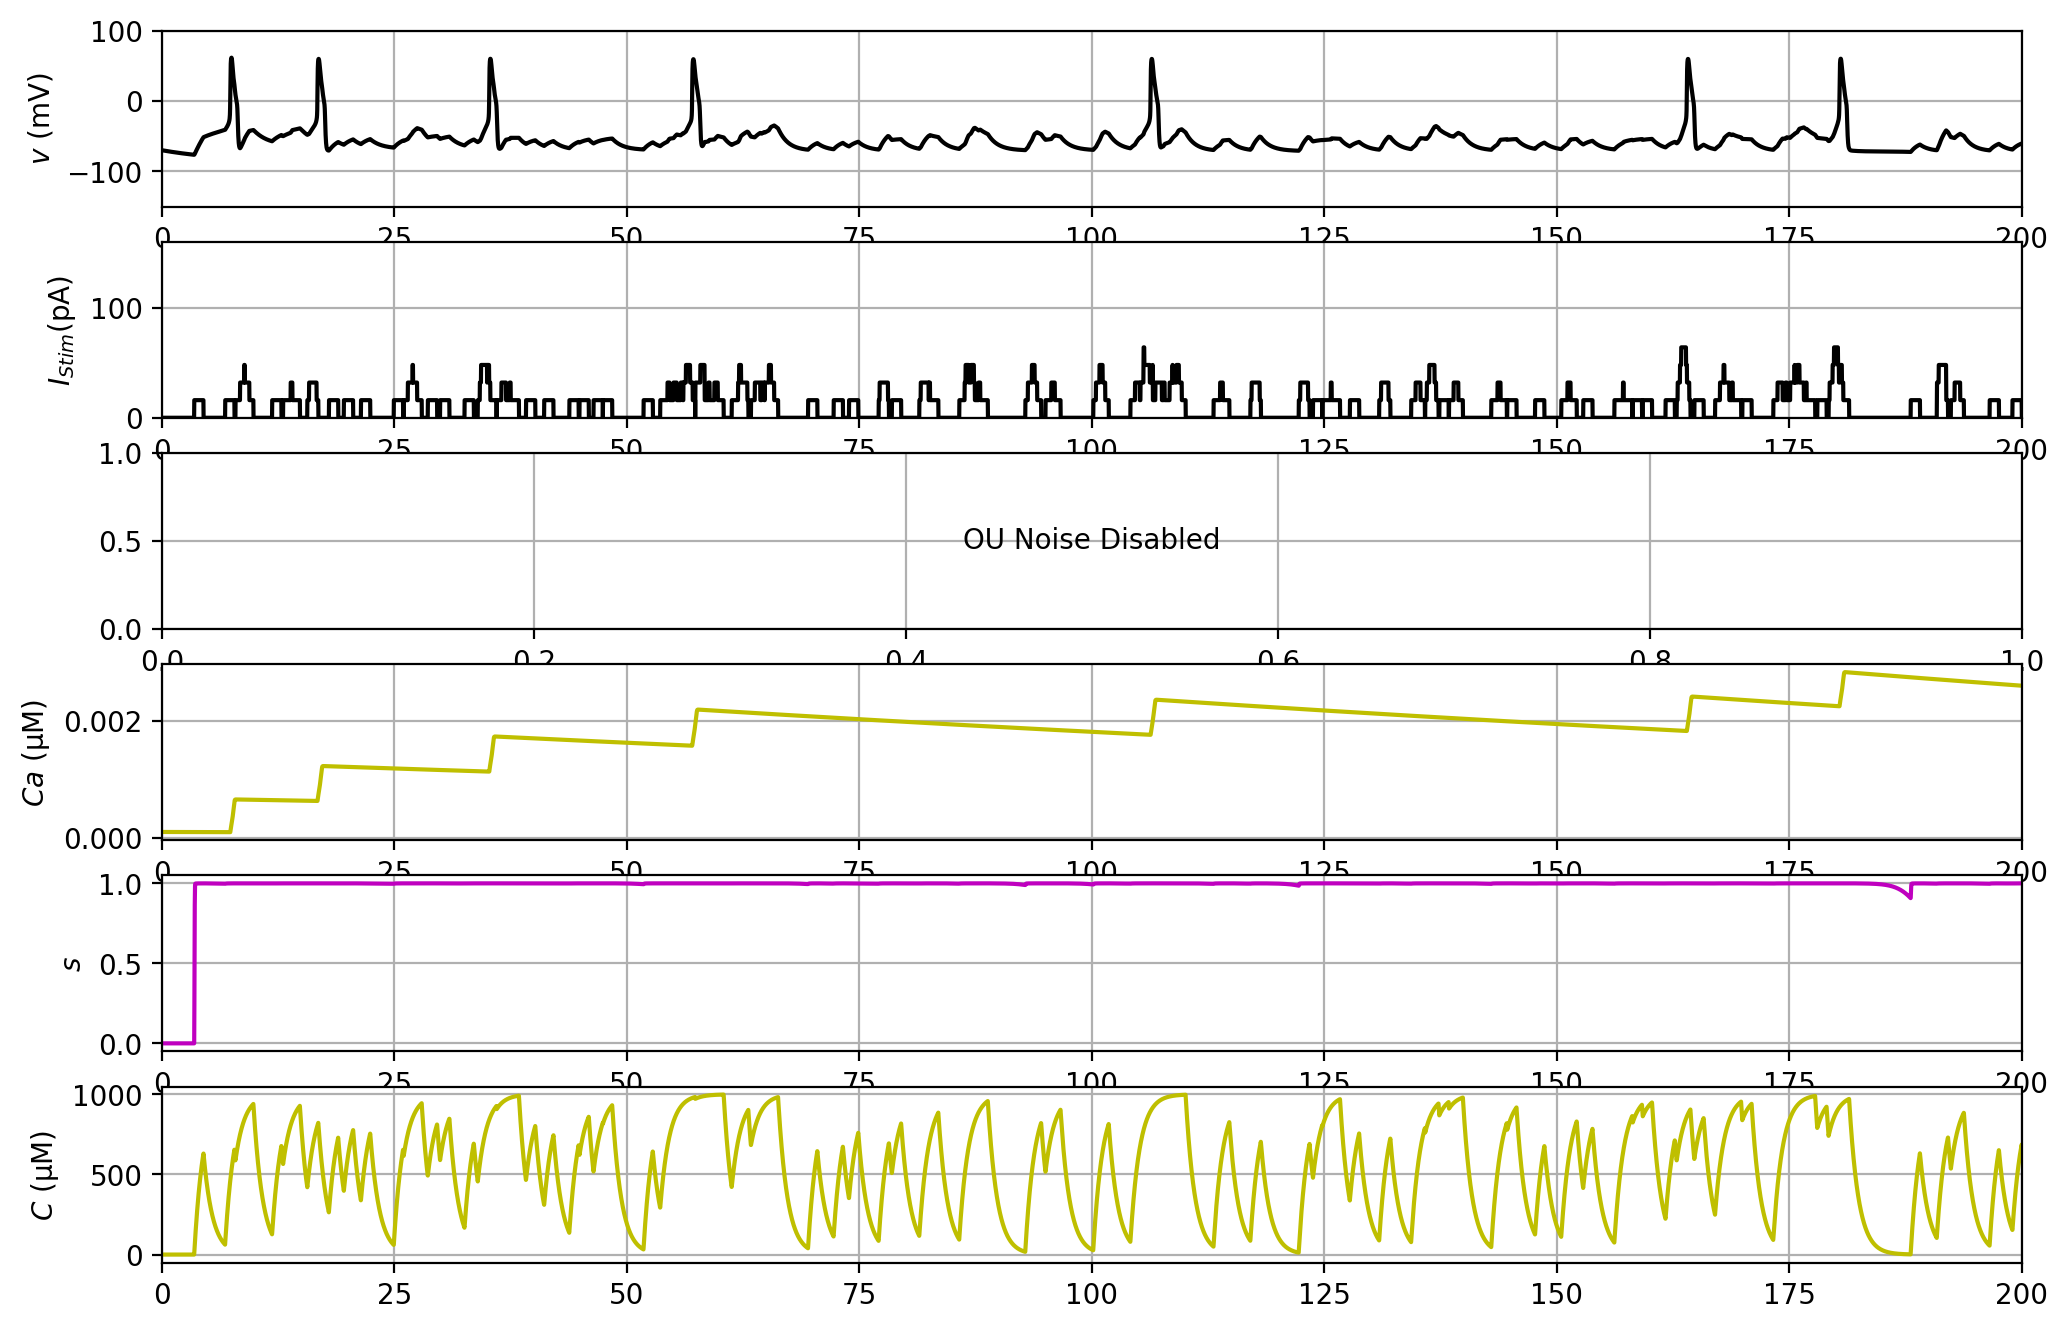

Número de espigas: 7
Frecuencia (Hz): 35.00175008750438


In [1]:
%run "Núcleo.ipynb" # Corremos el núcleo para aprovechar las simulaciones del otro código

# Compensación con entrada sináptica

### - Para compensación con gK(Ca) 

In [3]:
# Actualizamos parámetros para célula vieja y joven

p_old = copy.deepcopy(p)
p_old1 = copy.deepcopy(p)

Semilla = random.randint(1, 10000)

p_old['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old['gSyn']= 0.2 # conductancia sináptica
p_old['gK']= 200.0 # Conductancia del potasio K+
p_old['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old['gNa']= 30.0 # Conductancia del sodio Na+
p_old['gCa']= 2.0 # Conductancia del calcio 
p_old['gL']= 0.01 # Conductancia de fuga 

p_old1['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old1['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old1['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old1['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old1['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old1['gSyn']= 0.2 # conductancia sináptica
p_old1['gK']= 200.0 # Conductancia del potasio K+
p_old1['gK(Ca)']= 0.722 # Conductancia del potasio dependiente de calcio 
p_old1['gNa']= 30.0 # Conductancia del sodio Na+
p_old1['gCa']= 2.0 # Conductancia del calcio 
p_old1['gL']= 0.01 # Conductancia de fuga 

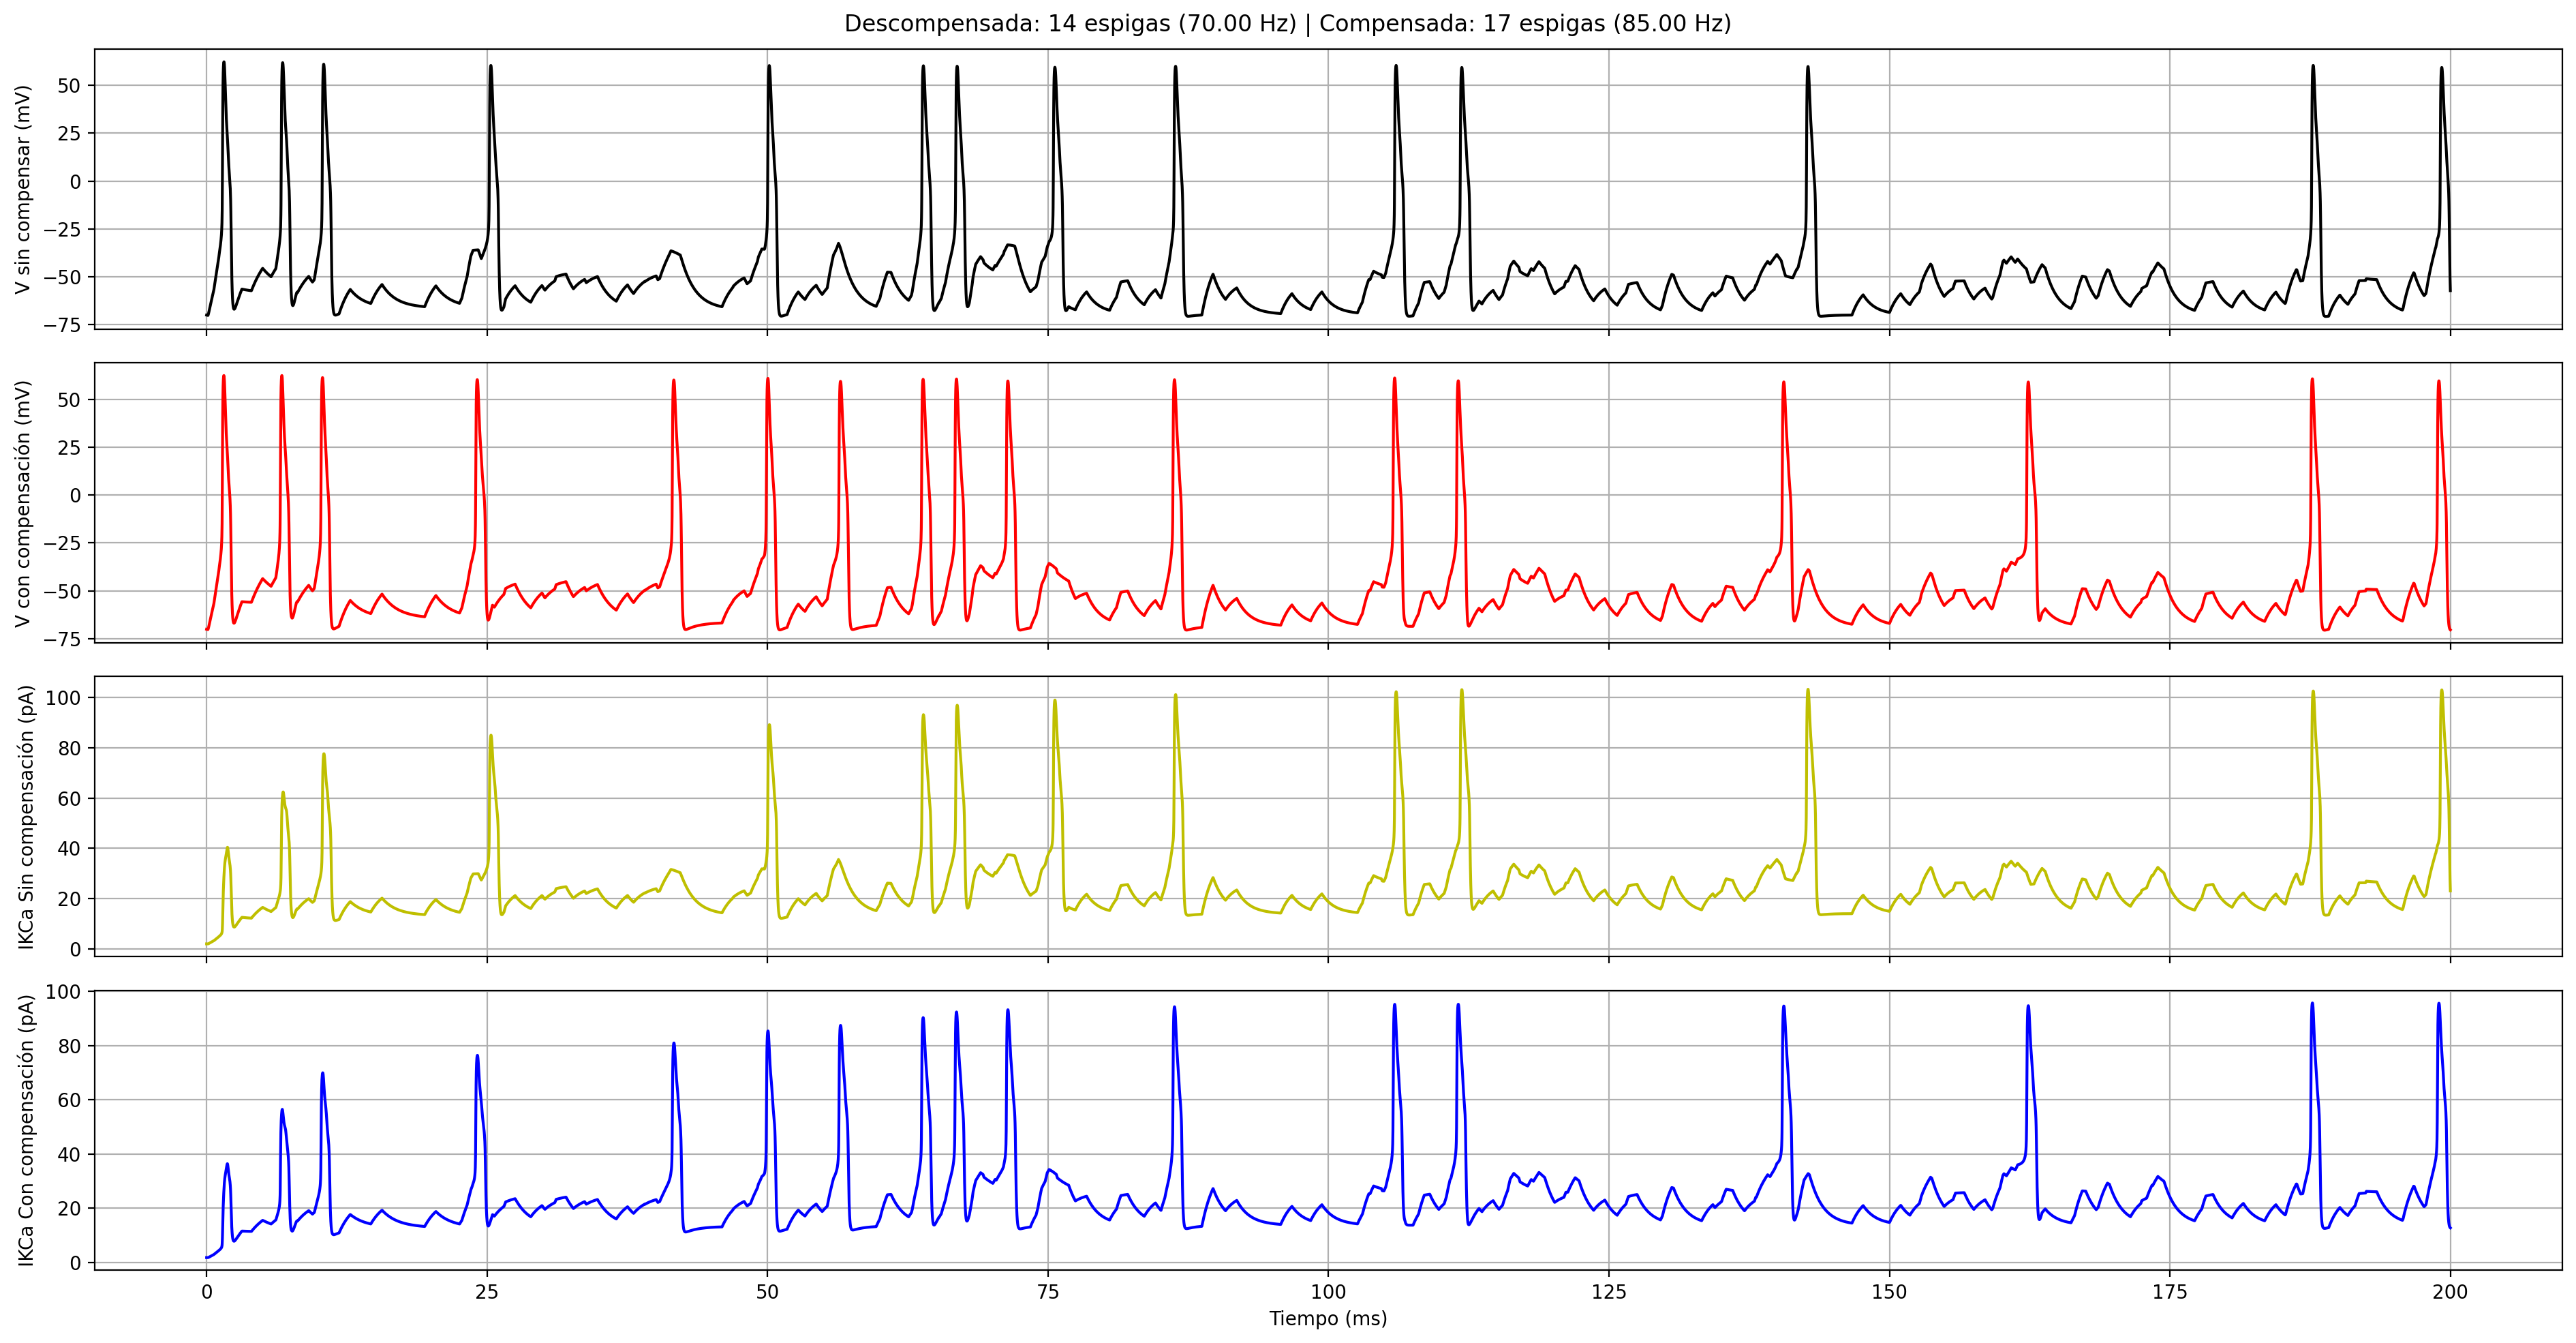

In [6]:
    # Simulaciones
   
    xx_old = simulateHH_numba(p_old, plot=False, seed=Semilla)
    xx_old1 = simulateHH_numba(p_old1, plot=False, seed=Semilla)

    # Conteo de espigas
    
    n_old, f_old, tiempos_old = contar_espigas(
        xx_old['sampTimes'],
        xx_old['v']
    )

    n_old1, f_old1, tiempos_old1 = contar_espigas(
        xx_old1['sampTimes'],
        xx_old1['v']
    )

    # GRÁFICA: solamente la simulación del valor actual

    fig, axs = plt.subplots(4, 1, figsize=(19, 10), sharex=True)

    axs[0].plot(
        xx_old['sampTimes'],
        xx_old['v'],
        label='sin compensación',
        color='k'
    )
    axs[0].set_ylabel('V sin compensar (mV)')
    axs[0].grid()

    axs[1].plot(
        xx_old1['sampTimes'],
        xx_old1['v'],
        label='Con compensación',
        color='r'
    )
    axs[1].set_ylabel('V con compensación (mV)')
    axs[1].grid()

    axs[2].plot(
        xx_old['sampTimes'],
        xx_old['IKCa'],
        label='Sin compensación',
        color='y'
    )
    axs[2].set_ylabel('IKCa Sin compensación (pA)')
    axs[2].grid()

    axs[3].plot(
        xx_old1['sampTimes'],
        xx_old1['IKCa'],
        label='Con compensación',
        color='b'
    )
    axs[3].set_ylabel('IKCa Con compensación (pA)')
    axs[3].set_xlabel('Tiempo (ms)')
    axs[3].grid()

    fig.suptitle(
        f'Descompensada: {n_old} espigas ({f_old:.2f} Hz) | '
        f'Compensada: {n_old1} espigas ({f_old1:.2f} Hz)'
    )

    plt.tight_layout()
    plt.show()

### -Para compensación con gSyn

In [8]:
# Actualizamos parámetros para célula vieja y joven

p_old = copy.deepcopy(p)
p_old1 = copy.deepcopy(p)

Semilla = random.randint(1, 10000)

p_old['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old['gSyn']= 0.2 # conductancia sináptica
p_old['gK']= 200.0 # Conductancia del potasio K+
p_old['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old['gNa']= 30.0 # Conductancia del sodio Na+
p_old['gCa']= 2.0 # Conductancia del calcio 
p_old['gL']= 0.01 # Conductancia de fuga 

p_old1['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old1['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old1['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old1['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old1['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old1['gSyn']= 0.281 # conductancia sináptica
p_old1['gK']= 200.0 # Conductancia del potasio K+
p_old1['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old1['gNa']= 30.0 # Conductancia del sodio Na+
p_old1['gCa']= 2.0 # Conductancia del calcio 
p_old1['gL']= 0.01 # Conductancia de fuga 

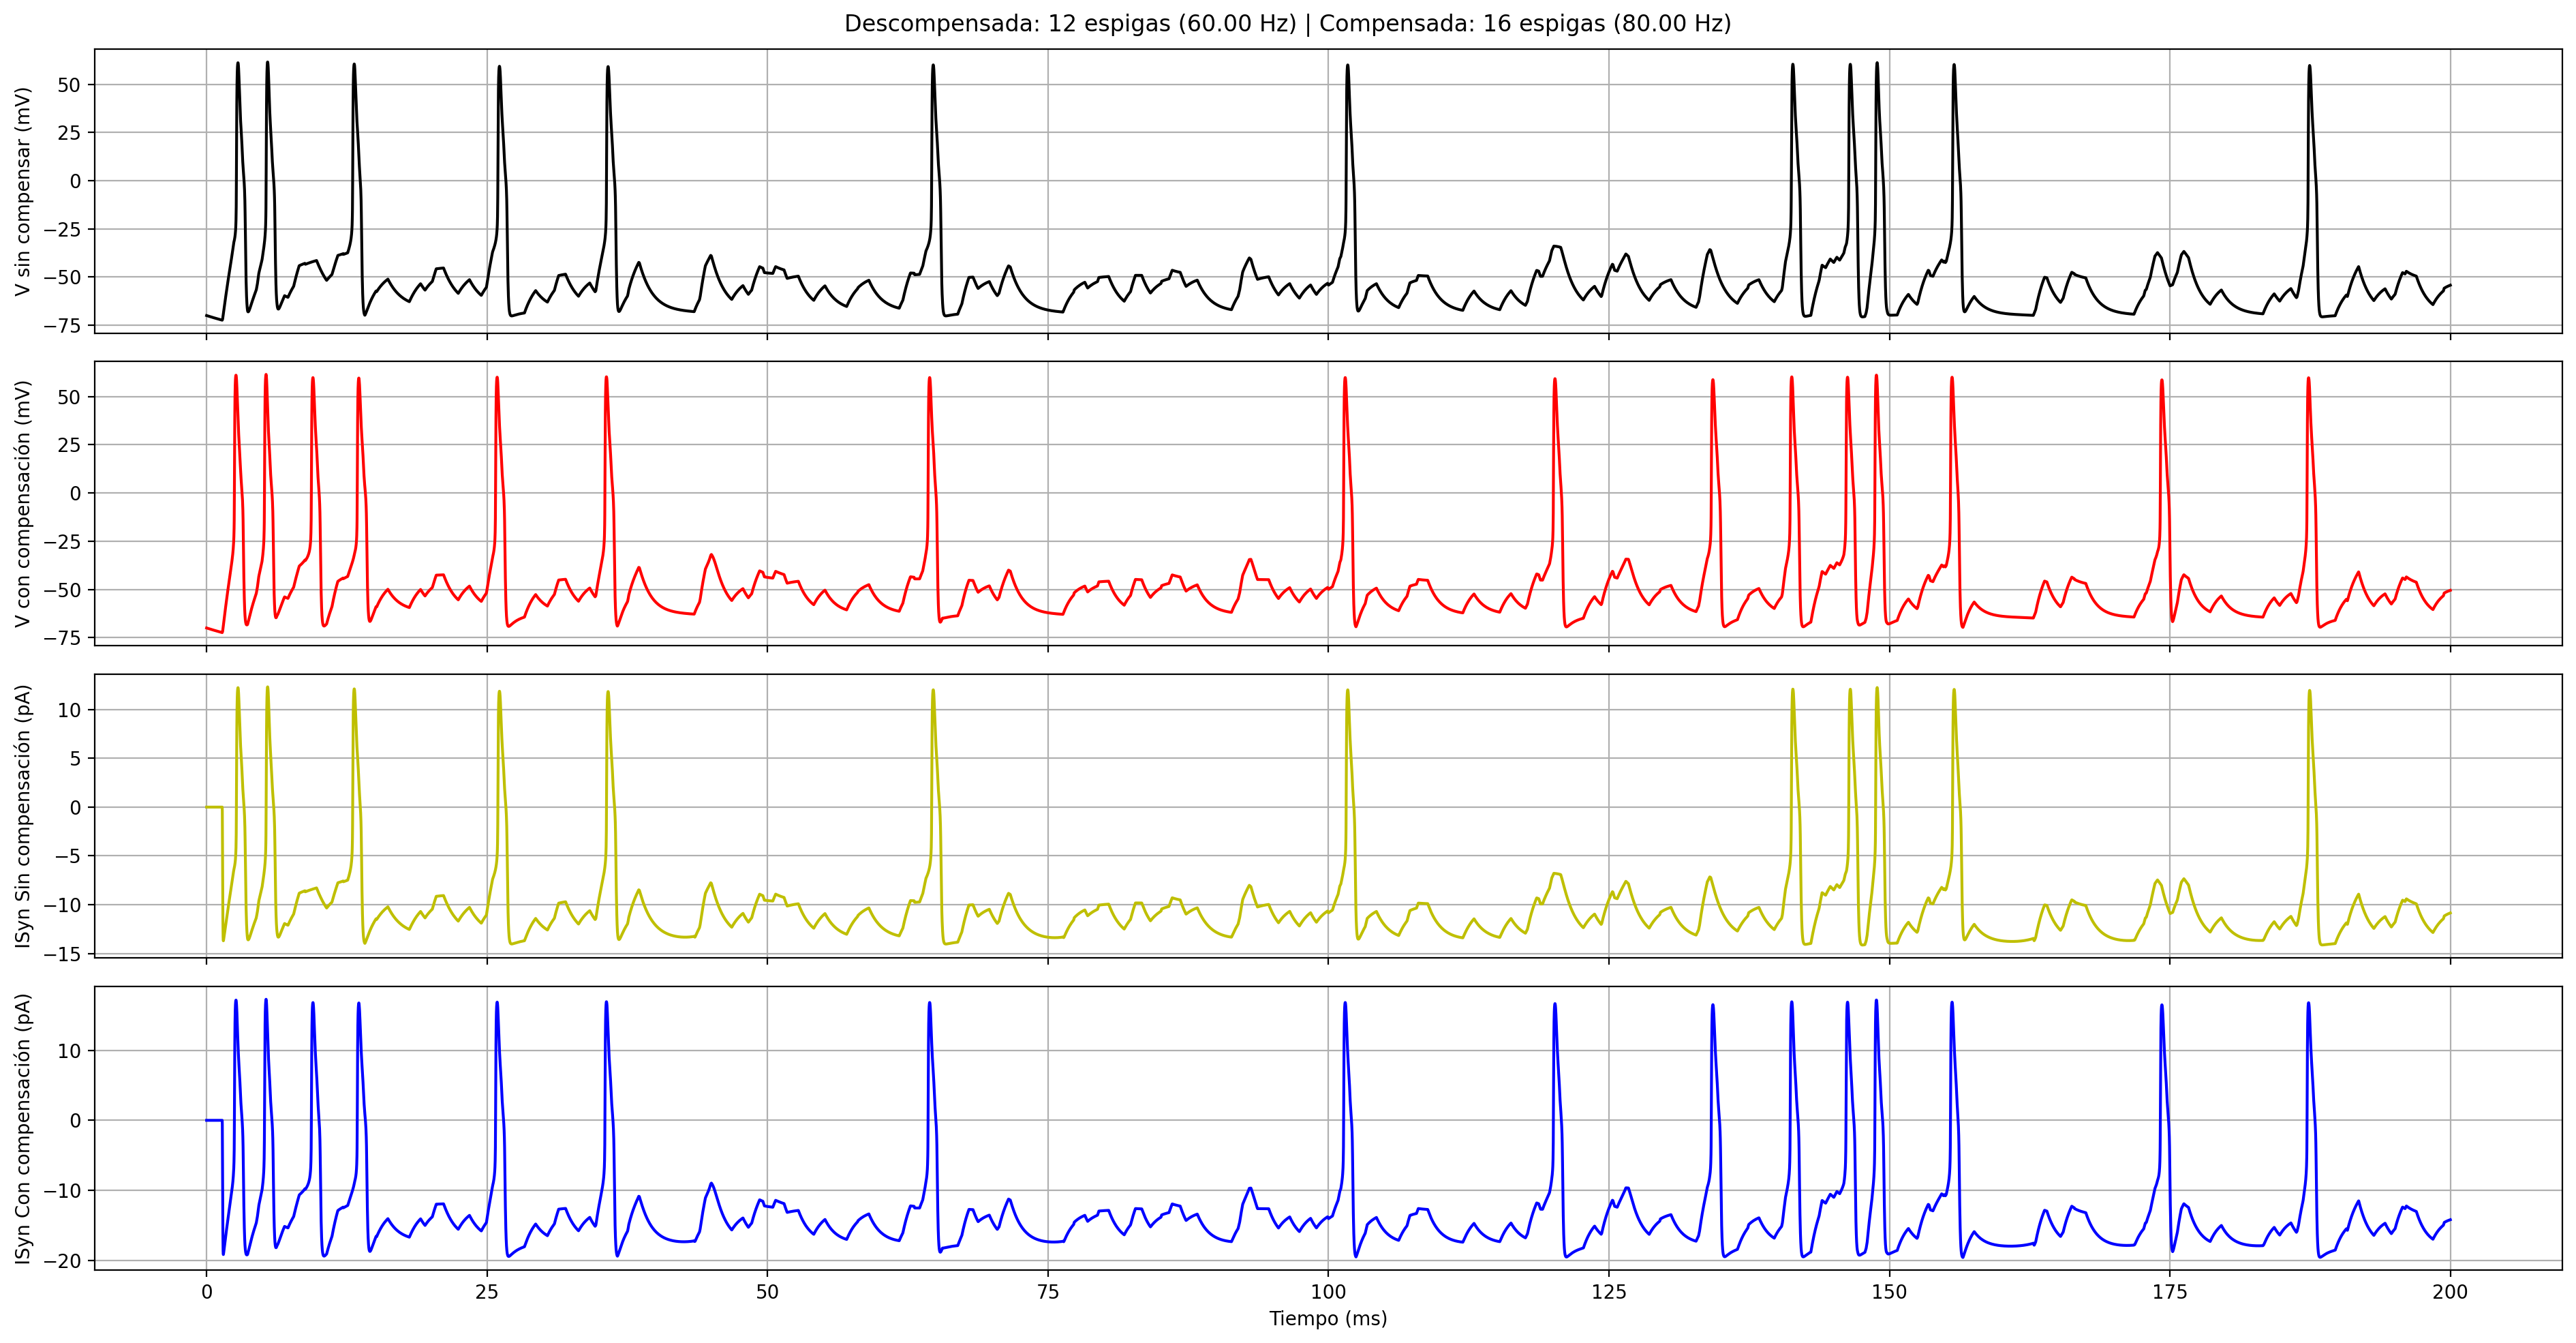

In [9]:
    # Simulaciones
   
    xx_old = simulateHH_numba(p_old, plot=False, seed=Semilla)
    xx_old1 = simulateHH_numba(p_old1, plot=False, seed=Semilla)

    # Conteo de espigas
    
    n_old, f_old, tiempos_old = contar_espigas(
        xx_old['sampTimes'],
        xx_old['v']
    )

    n_old1, f_old1, tiempos_old1 = contar_espigas(
        xx_old1['sampTimes'],
        xx_old1['v']
    )

    # GRÁFICA: solamente la simulación del valor actual

    fig, axs = plt.subplots(4, 1, figsize=(19, 10), sharex=True)

    axs[0].plot(
        xx_old['sampTimes'],
        xx_old['v'],
        label='sin compensación',
        color='k'
    )
    axs[0].set_ylabel('V sin compensar (mV)')
    axs[0].grid()

    axs[1].plot(
        xx_old1['sampTimes'],
        xx_old1['v'],
        label='Con compensación',
        color='r'
    )
    axs[1].set_ylabel('V con compensación (mV)')
    axs[1].grid()

    axs[2].plot(
        xx_old['sampTimes'],
        xx_old['Isyn'],
        label='Sin compensación',
        color='y'
    )
    axs[2].set_ylabel('ISyn Sin compensación (pA)')
    axs[2].grid()

    axs[3].plot(
        xx_old1['sampTimes'],
        xx_old1['Isyn'],
        label='Con compensación',
        color='b'
    )
    axs[3].set_ylabel('ISyn Con compensación (pA)')
    axs[3].set_xlabel('Tiempo (ms)')
    axs[3].grid()

    fig.suptitle(
        f'Descompensada: {n_old} espigas ({f_old:.2f} Hz) | '
        f'Compensada: {n_old1} espigas ({f_old1:.2f} Hz)'
    )

    plt.tight_layout()
    plt.show()

### -Para compensación con R

In [11]:
# Actualizamos parámetros para célula vieja y joven

p_old = copy.deepcopy(p)
p_old1 = copy.deepcopy(p)

Semilla = random.randint(1, 10000)

p_old['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old['gSyn']= 0.2 # conductancia sináptica
p_old['gK']= 200.0 # Conductancia del potasio K+
p_old['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old['gNa']= 30.0 # Conductancia del sodio Na+
p_old['gCa']= 2.0 # Conductancia del calcio 
p_old['gL']= 0.01 # Conductancia de fuga 
p_old['R']= 0.0045  # Tasa de eliminación del calcio intracelular (bombas/buffers)

p_old1['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old1['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old1['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old1['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old1['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old1['gSyn']= 0.2 # conductancia sináptica
p_old1['gK']= 200.0 # Conductancia del potasio K+
p_old1['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old1['gNa']= 30.0 # Conductancia del sodio Na+
p_old1['gCa']= 2.0 # Conductancia del calcio 
p_old1['gL']= 0.01 # Conductancia de fuga 
p_old1['R']= 0.0138  # Tasa de eliminación del calcio intracelular (bombas/buffers)

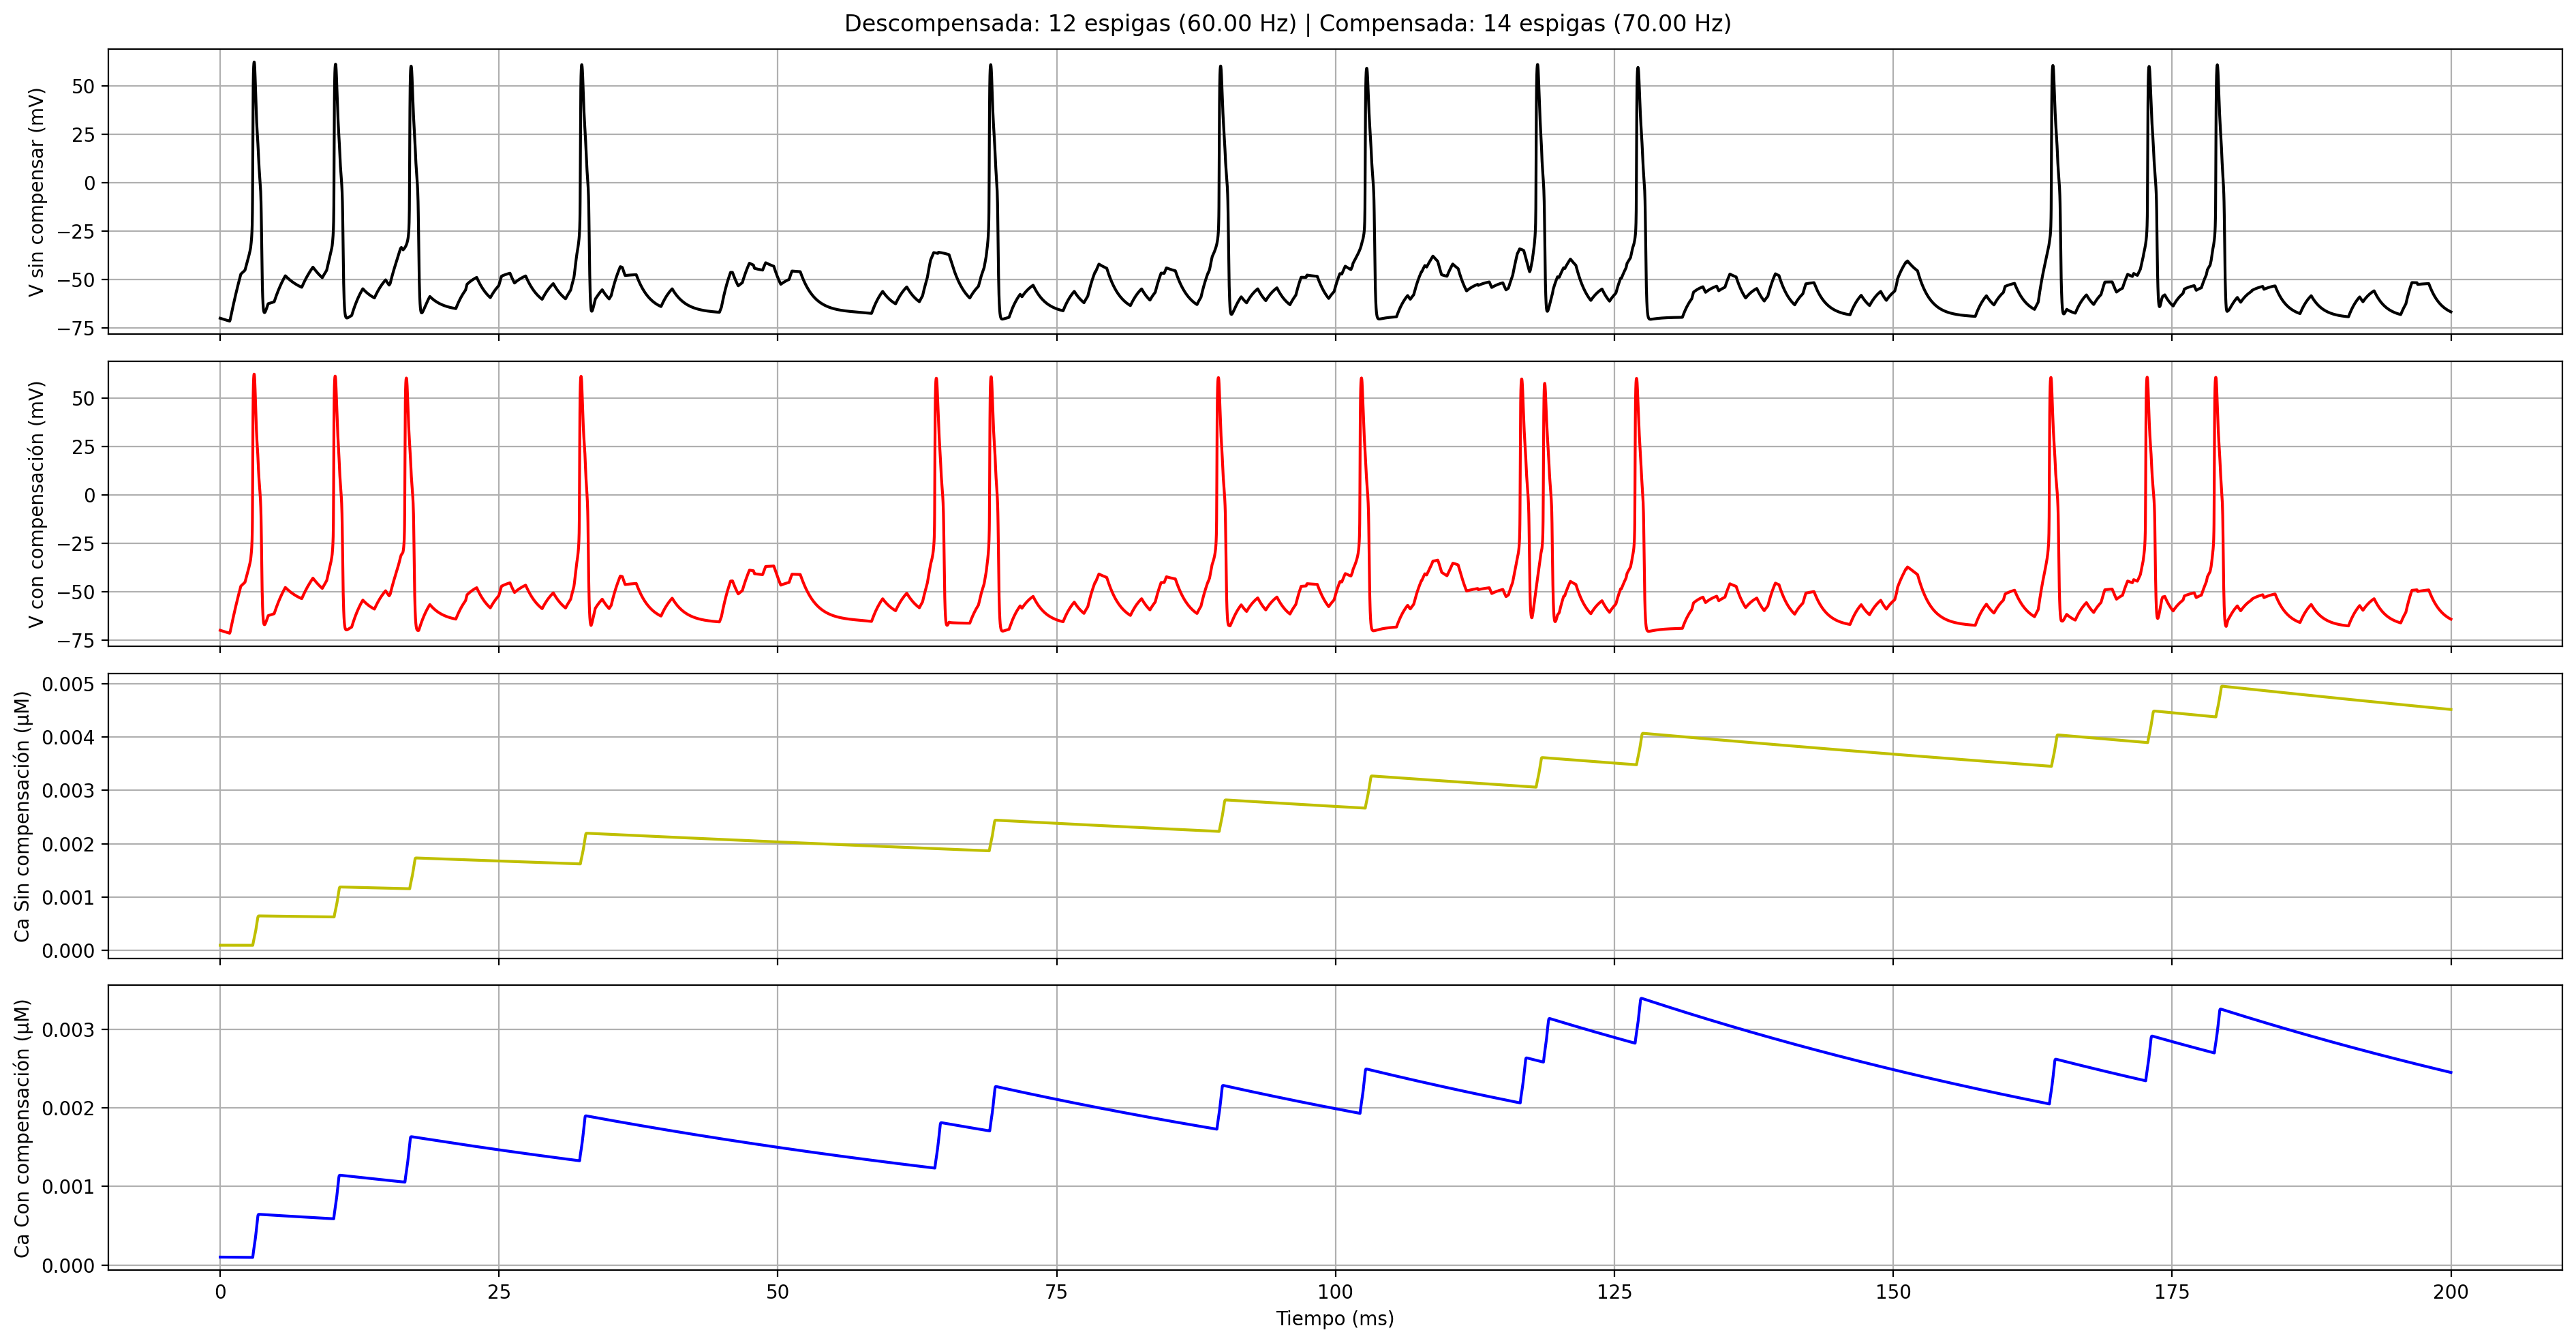

In [12]:
    # Simulaciones
   
    xx_old = simulateHH_numba(p_old, plot=False, seed=Semilla)
    xx_old1 = simulateHH_numba(p_old1, plot=False, seed=Semilla)

    # Conteo de espigas
    
    n_old, f_old, tiempos_old = contar_espigas(
        xx_old['sampTimes'],
        xx_old['v']
    )

    n_old1, f_old1, tiempos_old1 = contar_espigas(
        xx_old1['sampTimes'],
        xx_old1['v']
    )

    # GRÁFICA: solamente la simulación del valor actual

    fig, axs = plt.subplots(4, 1, figsize=(19, 10), sharex=True)

    axs[0].plot(
        xx_old['sampTimes'],
        xx_old['v'],
        label='sin compensación',
        color='k'
    )
    axs[0].set_ylabel('V sin compensar (mV)')
    axs[0].grid()

    axs[1].plot(
        xx_old1['sampTimes'],
        xx_old1['v'],
        label='Con compensación',
        color='r'
    )
    axs[1].set_ylabel('V con compensación (mV)')
    axs[1].grid()

    axs[2].plot(
        xx_old['sampTimes'],
        xx_old['c'],
        label='Sin compensación',
        color='y'
    )
    axs[2].set_ylabel('Ca Sin compensación (μM)')
    axs[2].grid()

    axs[3].plot(
        xx_old1['sampTimes'],
        xx_old1['c'],
        label='Con compensación',
        color='b'
    )
    axs[3].set_ylabel('Ca Con compensación (μM)')
    axs[3].set_xlabel('Tiempo (ms)')
    axs[3].grid()

    fig.suptitle(
        f'Descompensada: {n_old} espigas ({f_old:.2f} Hz) | '
        f'Compensada: {n_old1} espigas ({f_old1:.2f} Hz)'
    )

    plt.tight_layout()
    plt.show()

### -Para compensación con Kp

In [15]:
# Actualizamos parámetros para célula vieja y joven

p_old = copy.deepcopy(p)
p_old1 = copy.deepcopy(p)

Semilla = random.randint(1, 10000)

p_old['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old['gSyn']= 0.2 # conductancia sináptica
p_old['gK']= 200.0 # Conductancia del potasio K+
p_old['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old['gNa']= 30.0 # Conductancia del sodio Na+
p_old['gCa']= 2.0 # Conductancia del calcio 
p_old['gL']= 0.01 # Conductancia de fuga 
p_old['Kp']= 8.0e-6  # Conversión de corriente de Ca en cambio de concentración intracelular

p_old1['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old1['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old1['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old1['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old1['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old1['gSyn']= 0.2 # conductancia sináptica
p_old1['gK']= 200.0 # Conductancia del potasio K+
p_old1['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old1['gNa']= 30.0 # Conductancia del sodio Na+
p_old1['gCa']= 2.0 # Conductancia del calcio 
p_old1['gL']= 0.01 # Conductancia de fuga 
p_old1['Kp']= 3.6e-6  # Conversión de corriente de Ca en cambio de concentración intracelular

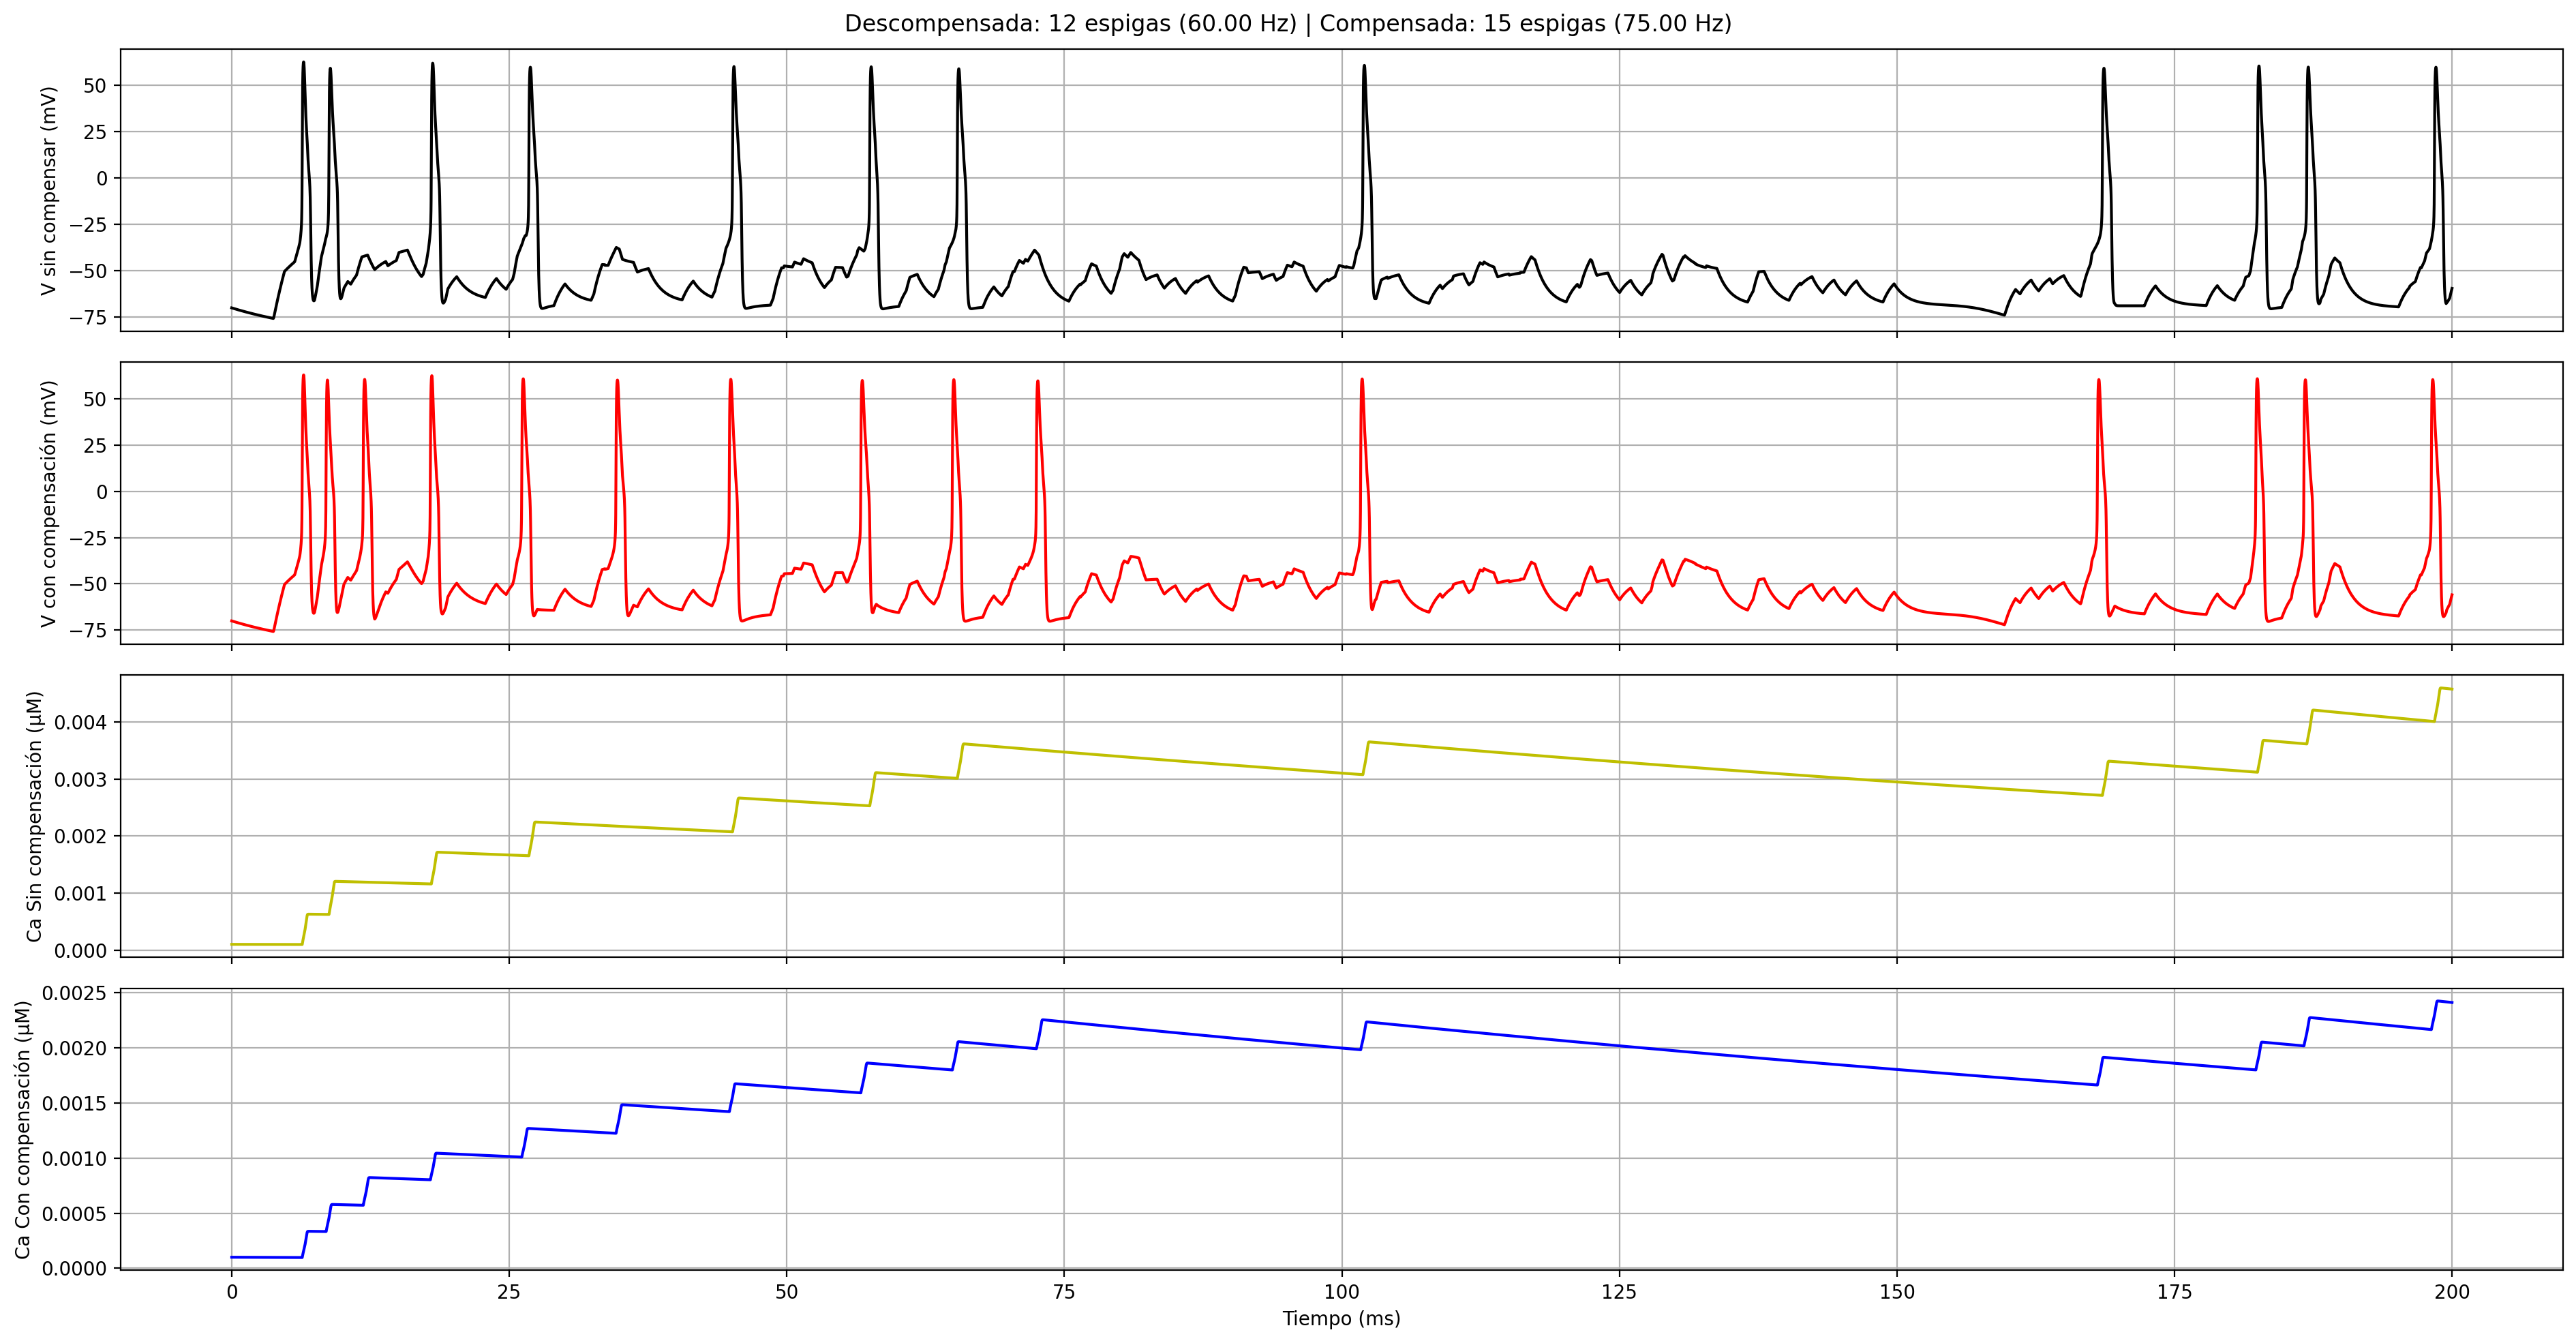

In [16]:
    # Simulaciones
   
    xx_old = simulateHH_numba(p_old, plot=False, seed=Semilla)
    xx_old1 = simulateHH_numba(p_old1, plot=False, seed=Semilla)

    # Conteo de espigas
    
    n_old, f_old, tiempos_old = contar_espigas(
        xx_old['sampTimes'],
        xx_old['v']
    )

    n_old1, f_old1, tiempos_old1 = contar_espigas(
        xx_old1['sampTimes'],
        xx_old1['v']
    )

    # GRÁFICA: solamente la simulación del valor actual

    fig, axs = plt.subplots(4, 1, figsize=(19, 10), sharex=True)

    axs[0].plot(
        xx_old['sampTimes'],
        xx_old['v'],
        label='sin compensación',
        color='k'
    )
    axs[0].set_ylabel('V sin compensar (mV)')
    axs[0].grid()

    axs[1].plot(
        xx_old1['sampTimes'],
        xx_old1['v'],
        label='Con compensación',
        color='r'
    )
    axs[1].set_ylabel('V con compensación (mV)')
    axs[1].grid()

    axs[2].plot(
        xx_old['sampTimes'],
        xx_old['c'],
        label='Sin compensación',
        color='y'
    )
    axs[2].set_ylabel('Ca Sin compensación (μM)')
    axs[2].grid()

    axs[3].plot(
        xx_old1['sampTimes'],
        xx_old1['c'],
        label='Con compensación',
        color='b'
    )
    axs[3].set_ylabel('Ca Con compensación (μM)')
    axs[3].set_xlabel('Tiempo (ms)')
    axs[3].grid()

    fig.suptitle(
        f'Descompensada: {n_old} espigas ({f_old:.2f} Hz) | '
        f'Compensada: {n_old1} espigas ({f_old1:.2f} Hz)'
    )

    plt.tight_layout()
    plt.show()

### -Para compensación con amplitud de pulso

In [25]:
# Actualizamos parámetros para célula vieja y joven

p_old = copy.deepcopy(p)
p_old1 = copy.deepcopy(p)

Semilla = random.randint(1, 10000)

p_old['pulseAmp'] = 16.0 # Amplitud del pulso  
p_old['pulseRate'] = 0.75 # λ del Poisson
p_old['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old['gSyn']= 0.2 # conductancia sináptica
p_old['gK']= 200.0 # Conductancia del potasio K+
p_old['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old['gNa']= 30.0 # Conductancia del sodio Na+
p_old['gCa']= 2.0 # Conductancia del calcio 
p_old['gL']= 0.01 # Conductancia de fuga 
p_old['Kp']= 8.0e-6  # Conversión de corriente de Ca en cambio de concentración intracelular

p_old1['pulseAmp'] = 19.0 # Amplitud del pulso  
p_old1['pulseRate'] = 0.75 # λ del Poisson
p_old1['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old1['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old1['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old1['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old1['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old1['gSyn']= 0.2 # conductancia sináptica
p_old1['gK']= 200.0 # Conductancia del potasio K+
p_old1['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old1['gNa']= 30.0 # Conductancia del sodio Na+
p_old1['gCa']= 2.0 # Conductancia del calcio 
p_old1['gL']= 0.01 # Conductancia de fuga 
p_old1['Kp']= 3.6e-6  # Conversión de corriente de Ca en cambio de concentración intracelular

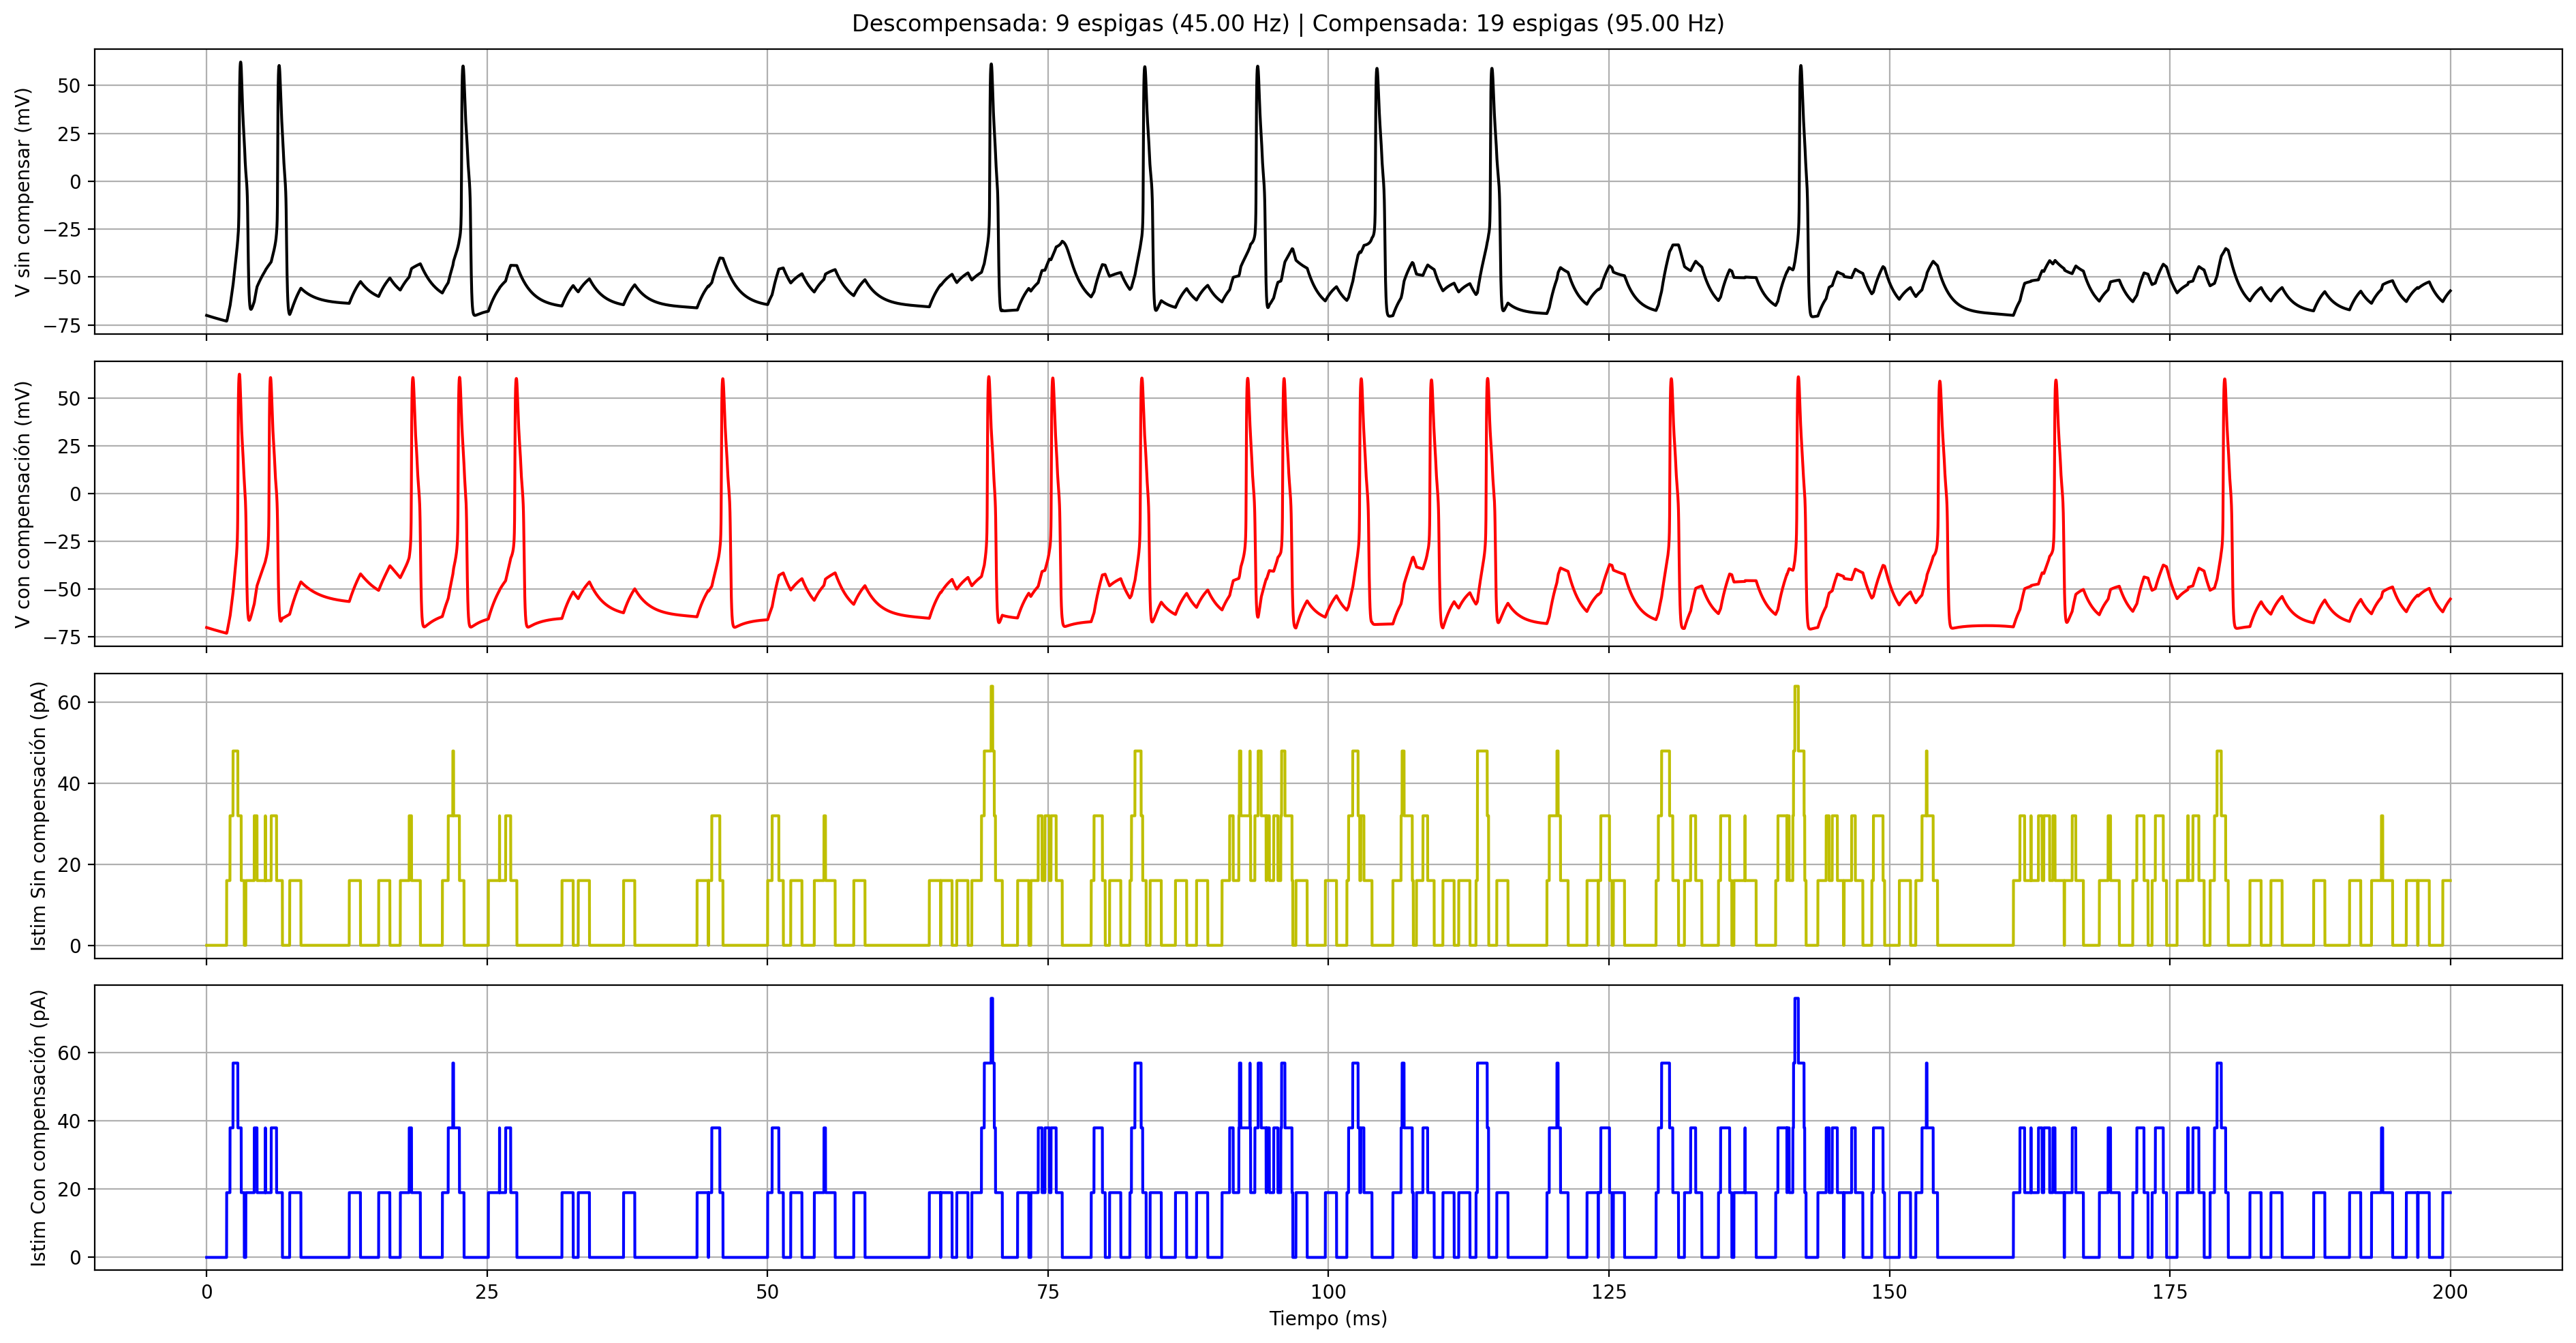

In [26]:
    # Simulaciones
   
    xx_old = simulateHH_numba(p_old, plot=False, seed=Semilla)
    xx_old1 = simulateHH_numba(p_old1, plot=False, seed=Semilla)

    # Conteo de espigas
    
    n_old, f_old, tiempos_old = contar_espigas(
        xx_old['sampTimes'],
        xx_old['v']
    )

    n_old1, f_old1, tiempos_old1 = contar_espigas(
        xx_old1['sampTimes'],
        xx_old1['v']
    )

    # GRÁFICA: solamente la simulación del valor actual

    fig, axs = plt.subplots(4, 1, figsize=(19, 10), sharex=True)

    axs[0].plot(
        xx_old['sampTimes'],
        xx_old['v'],
        label='sin compensación',
        color='k'
    )
    axs[0].set_ylabel('V sin compensar (mV)')
    axs[0].grid()

    axs[1].plot(
        xx_old1['sampTimes'],
        xx_old1['v'],
        label='Con compensación',
        color='r'
    )
    axs[1].set_ylabel('V con compensación (mV)')
    axs[1].grid()

    axs[2].plot(
        xx_old['sampTimes'],
        xx_old['IStim'],
        label='Sin compensación',
        color='y'
    )
    axs[2].set_ylabel('Istim Sin compensación (pA)')
    axs[2].grid()

    axs[3].plot(
        xx_old1['sampTimes'],
        xx_old1['IStim'],
        label='Con compensación',
        color='b'
    )
    axs[3].set_ylabel('Istim Con compensación (pA)')
    axs[3].set_xlabel('Tiempo (ms)')
    axs[3].grid()

    fig.suptitle(
        f'Descompensada: {n_old} espigas ({f_old:.2f} Hz) | '
        f'Compensada: {n_old1} espigas ({f_old1:.2f} Hz)'
    )

    plt.tight_layout()
    plt.show()

### -Para compensación con frecuencia de pulso

In [27]:
# Actualizamos parámetros para célula vieja y joven

p_old = copy.deepcopy(p)
p_old1 = copy.deepcopy(p)

Semilla = random.randint(1, 10000)

p_old['pulseAmp'] = 16.0 # Amplitud del pulso  
p_old['pulseRate'] = 0.75 # λ del Poisson
p_old['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old['gSyn']= 0.2 # conductancia sináptica
p_old['gK']= 200.0 # Conductancia del potasio K+
p_old['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old['gNa']= 30.0 # Conductancia del sodio Na+
p_old['gCa']= 2.0 # Conductancia del calcio 
p_old['gL']= 0.01 # Conductancia de fuga 
p_old['Kp']= 8.0e-6  # Conversión de corriente de Ca en cambio de concentración intracelular

p_old1['pulseAmp'] = 16.0 # Amplitud del pulso  
p_old1['pulseRate'] = 0.945 # λ del Poisson
p_old1['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old1['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old1['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old1['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old1['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old1['gSyn']= 0.2 # conductancia sináptica
p_old1['gK']= 200.0 # Conductancia del potasio K+
p_old1['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old1['gNa']= 30.0 # Conductancia del sodio Na+
p_old1['gCa']= 2.0 # Conductancia del calcio 
p_old1['gL']= 0.01 # Conductancia de fuga 
p_old1['Kp']= 3.6e-6  # Conversión de corriente de Ca en cambio de concentración intracelular

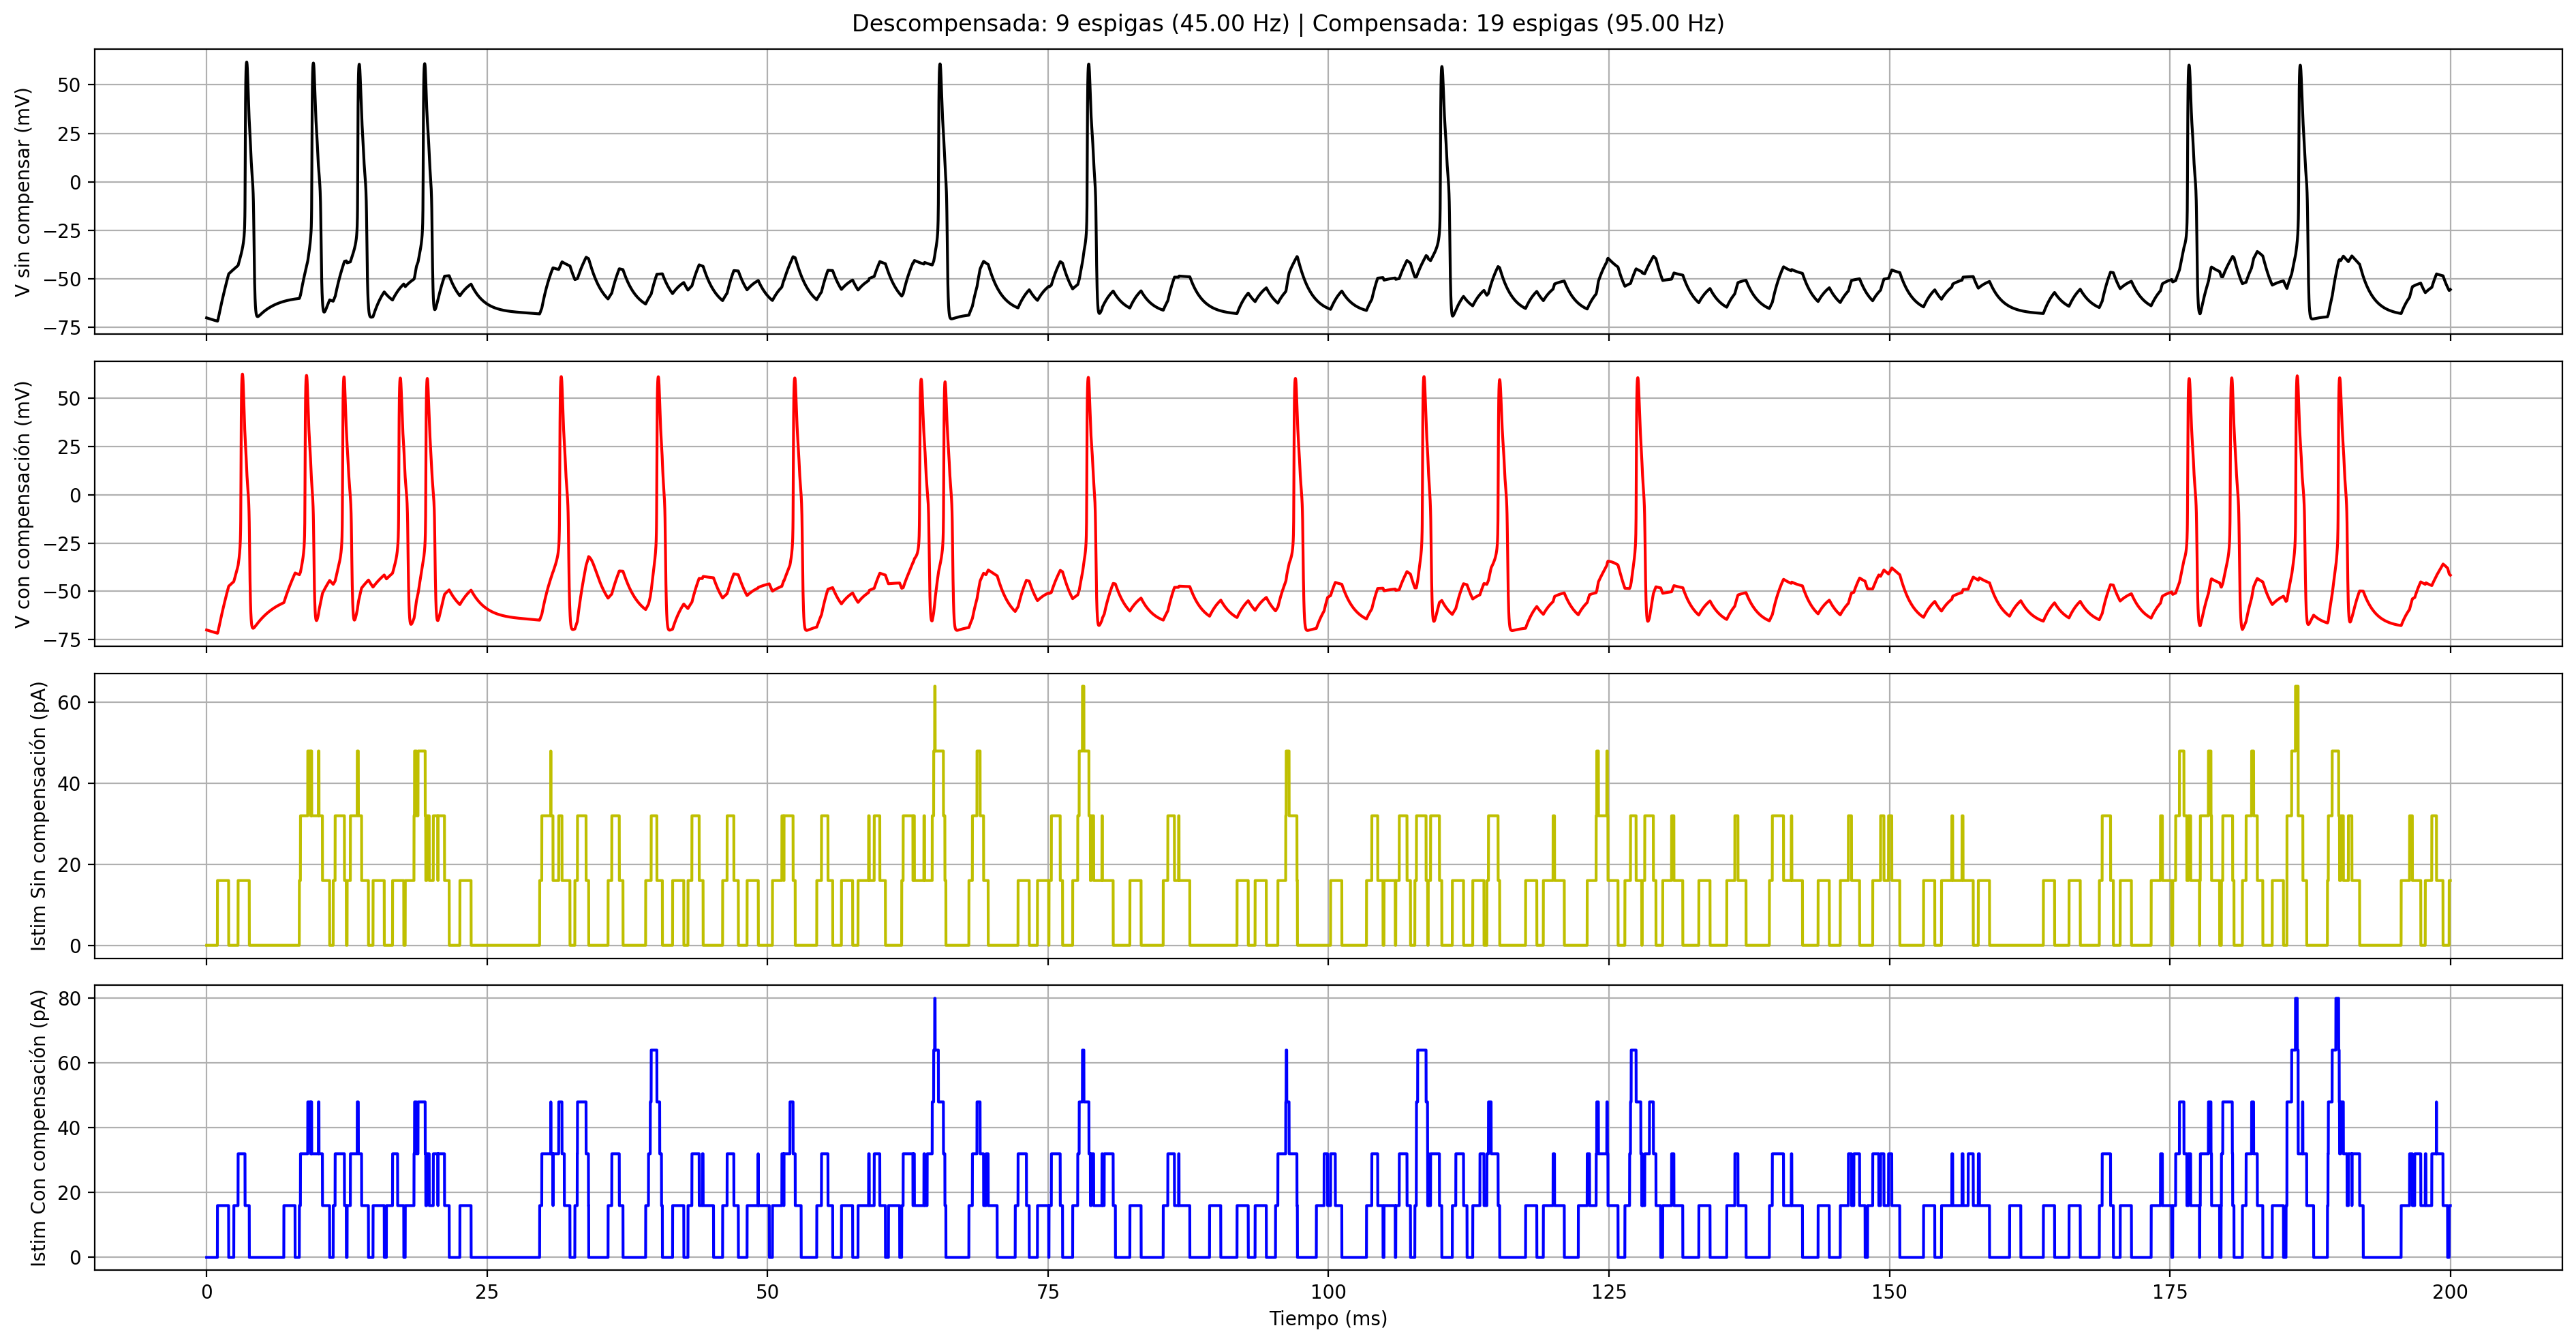

In [28]:
    # Simulaciones
   
    xx_old = simulateHH_numba(p_old, plot=False, seed=Semilla)
    xx_old1 = simulateHH_numba(p_old1, plot=False, seed=Semilla)

    # Conteo de espigas
    
    n_old, f_old, tiempos_old = contar_espigas(
        xx_old['sampTimes'],
        xx_old['v']
    )

    n_old1, f_old1, tiempos_old1 = contar_espigas(
        xx_old1['sampTimes'],
        xx_old1['v']
    )

    # GRÁFICA: solamente la simulación del valor actual

    fig, axs = plt.subplots(4, 1, figsize=(19, 10), sharex=True)

    axs[0].plot(
        xx_old['sampTimes'],
        xx_old['v'],
        label='sin compensación',
        color='k'
    )
    axs[0].set_ylabel('V sin compensar (mV)')
    axs[0].grid()

    axs[1].plot(
        xx_old1['sampTimes'],
        xx_old1['v'],
        label='Con compensación',
        color='r'
    )
    axs[1].set_ylabel('V con compensación (mV)')
    axs[1].grid()

    axs[2].plot(
        xx_old['sampTimes'],
        xx_old['IStim'],
        label='Sin compensación',
        color='y'
    )
    axs[2].set_ylabel('Istim Sin compensación (pA)')
    axs[2].grid()

    axs[3].plot(
        xx_old1['sampTimes'],
        xx_old1['IStim'],
        label='Con compensación',
        color='b'
    )
    axs[3].set_ylabel('Istim Con compensación (pA)')
    axs[3].set_xlabel('Tiempo (ms)')
    axs[3].grid()

    fig.suptitle(
        f'Descompensada: {n_old} espigas ({f_old:.2f} Hz) | '
        f'Compensada: {n_old1} espigas ({f_old1:.2f} Hz)'
    )

    plt.tight_layout()
    plt.show()

# Para compensación con inyección de corriente 

### - Para gK(Ca)

In [17]:
# Actualizamos parámetros para célula vieja y joven

p_old = copy.deepcopy(p)
p_old1 = copy.deepcopy(p)

Semilla = random.randint(1, 10000)

p_old['upStart']=0.0 # Inicio de la fase de despolarización del estímulo de la corriente
p_old['upStop']=0.01 # Fin de la fase de despolarización del estímulo de corriente
p_old['dnStart']=200.0 # Inicio de fase de repolarización del estímulo de corriente
p_old['dnStop']=200.01 # Fin de fase de repolarización del estímulo de corriente
p_old['rampAmp']=30.0 # Amplitud del estímulo de corriente
p_old['usePulseTrain'] = False # Activar tren de pulsos
p_old['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old['gSyn']= 0.2 # conductancia sináptica
p_old['gK']= 200.0 # Conductancia del potasio K+
p_old['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old['gNa']= 30.0 # Conductancia del sodio Na+
p_old['gCa']= 2.0 # Conductancia del calcio 
p_old['gL']= 0.01 # Conductancia de fuga 

p_old1['upStart']=0.0 # Inicio de la fase de despolarización del estímulo de la corriente
p_old1['upStop']=0.01 # Fin de la fase de despolarización del estímulo de corriente
p_old1['dnStart']=200.0 # Inicio de fase de repolarización del estímulo de corriente
p_old1['dnStop']=200.01 # Fin de fase de repolarización del estímulo de corriente
p_old1['rampAmp']=30.0 # Amplitud del estímulo de corriente
p_old1['usePulseTrain'] = False # Activar tren de pulsos
p_old1['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old1['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old1['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old1['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old1['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old1['gSyn']= 0.2 # conductancia sináptica
p_old1['gK']= 200.0 # Conductancia del potasio K+
p_old1['gK(Ca)']= 0.720 # Conductancia del potasio dependiente de calcio 
p_old1['gNa']= 30.0 # Conductancia del sodio Na+
p_old1['gCa']= 2.0 # Conductancia del calcio 
p_old1['gL']= 0.01 # Conductancia de fuga 

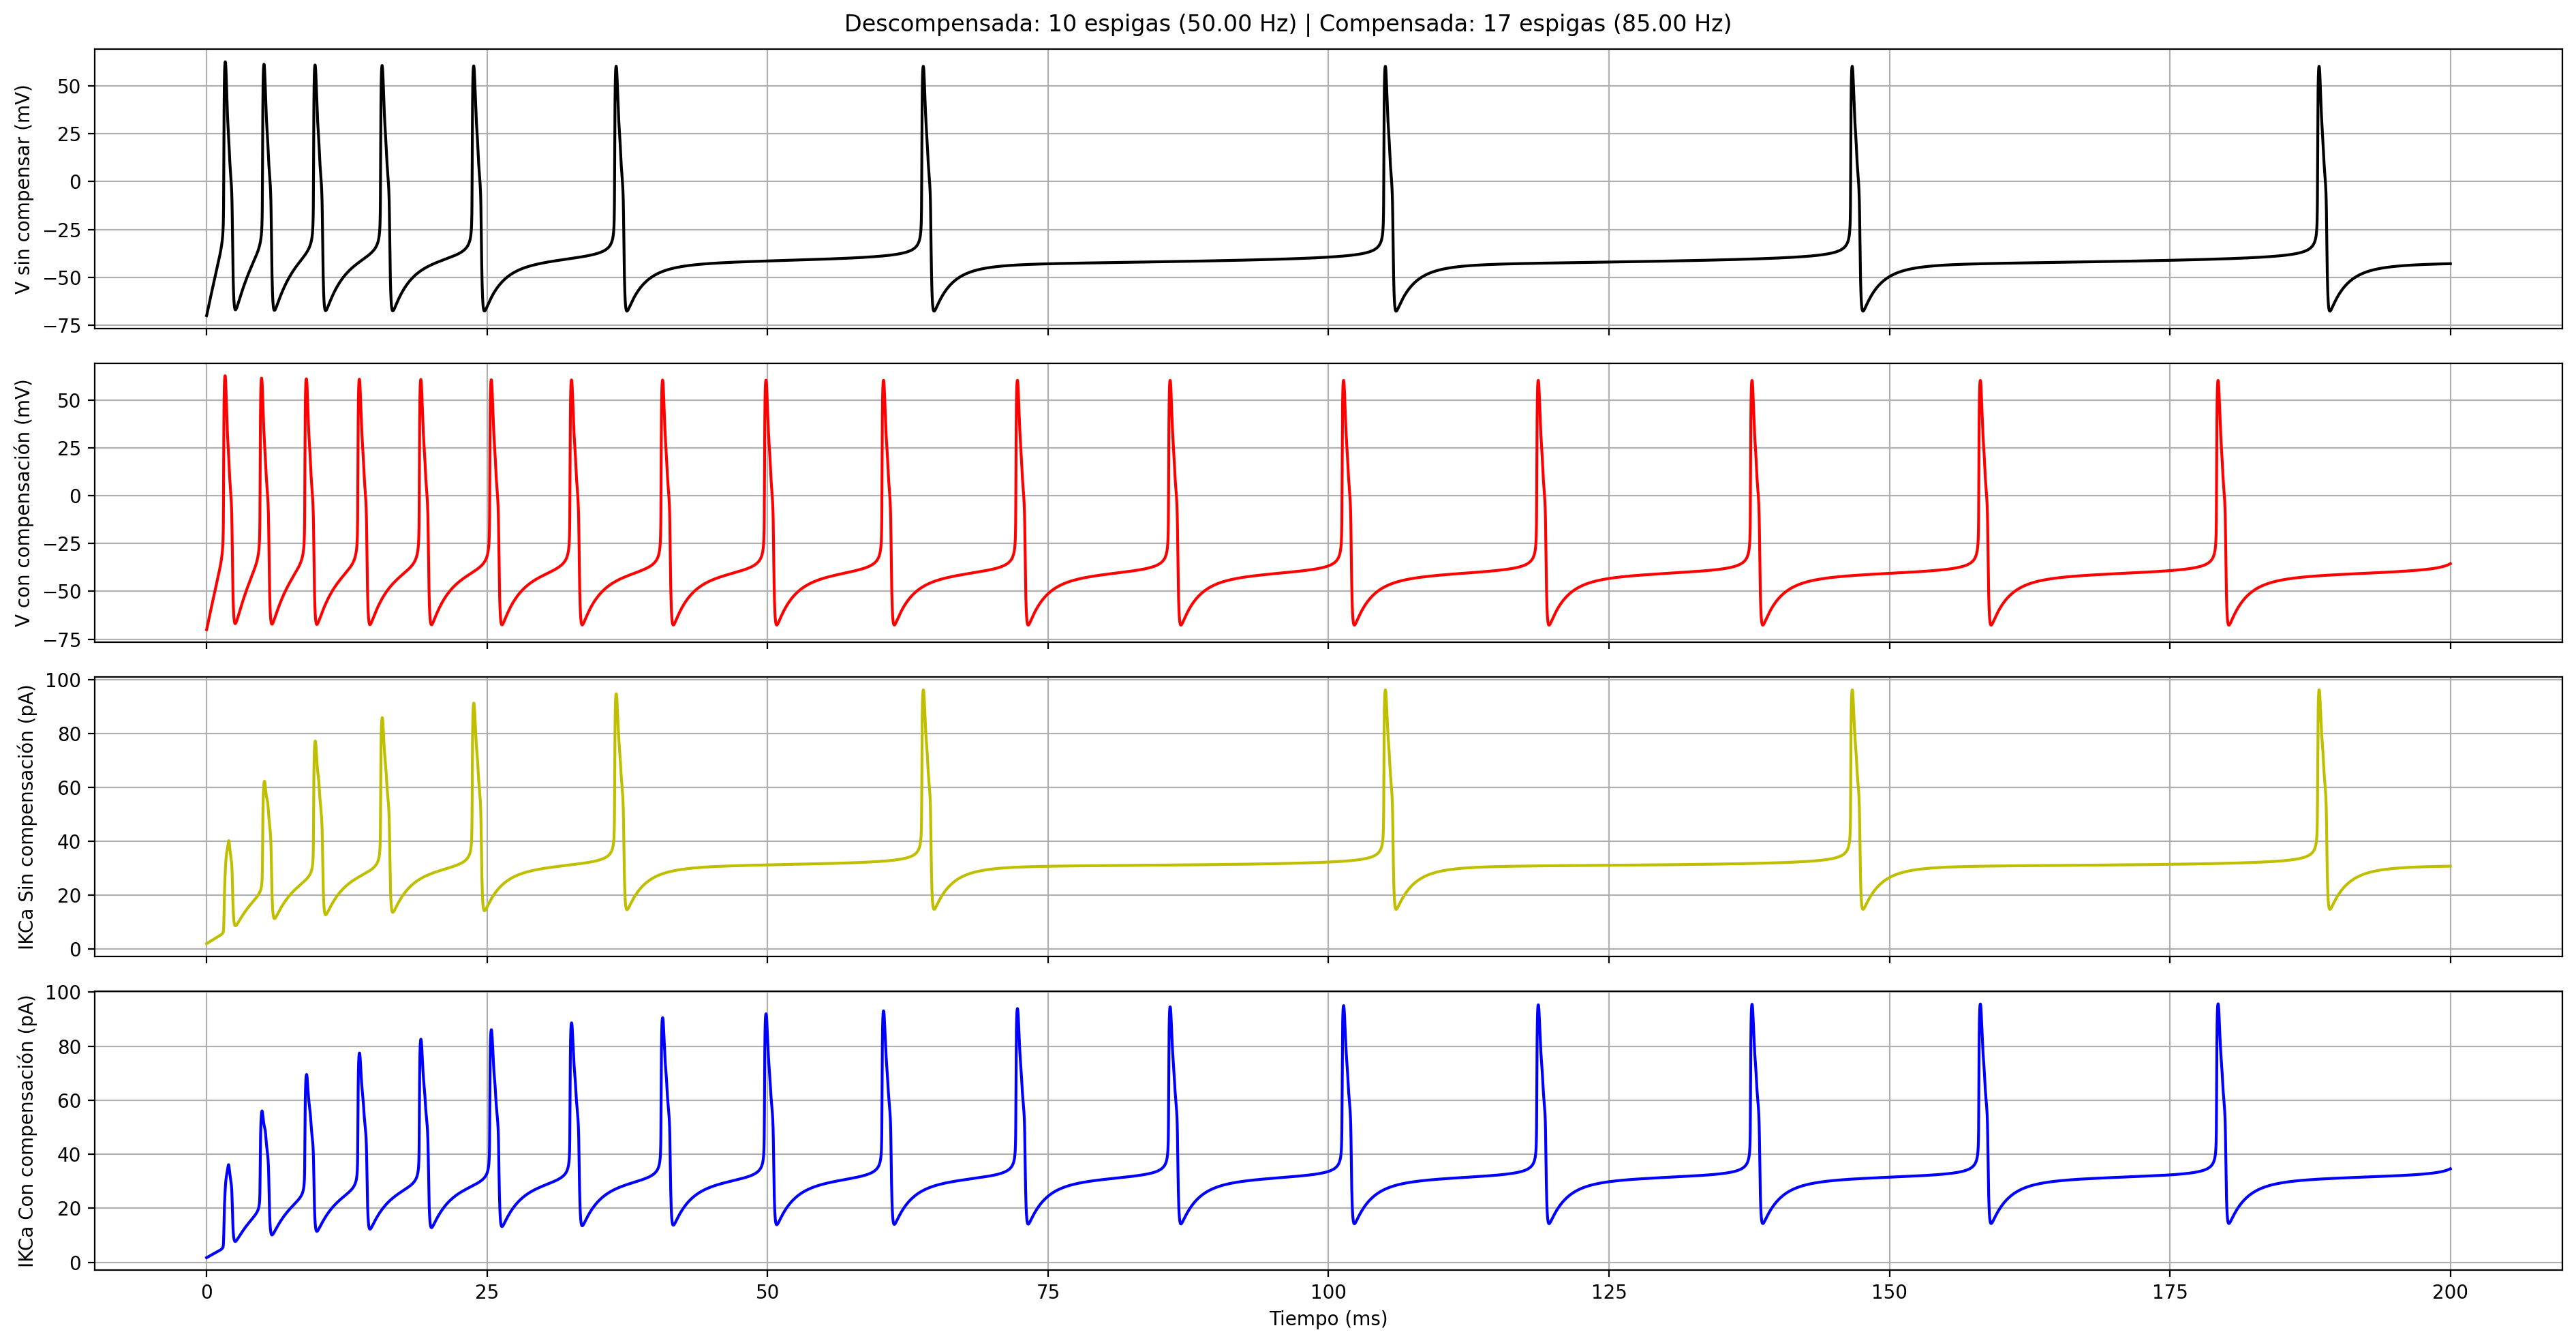

In [18]:
    # Simulaciones
   
    xx_old = simulateHH_numba(p_old, plot=False, seed=Semilla)
    xx_old1 = simulateHH_numba(p_old1, plot=False, seed=Semilla)

    # Conteo de espigas
    
    n_old, f_old, tiempos_old = contar_espigas(
        xx_old['sampTimes'],
        xx_old['v']
    )

    n_old1, f_old1, tiempos_old1 = contar_espigas(
        xx_old1['sampTimes'],
        xx_old1['v']
    )

    # GRÁFICA: solamente la simulación del valor actual

    fig, axs = plt.subplots(4, 1, figsize=(19, 10), sharex=True)

    axs[0].plot(
        xx_old['sampTimes'],
        xx_old['v'],
        label='sin compensación',
        color='k'
    )
    axs[0].set_ylabel('V sin compensar (mV)')
    axs[0].grid()

    axs[1].plot(
        xx_old1['sampTimes'],
        xx_old1['v'],
        label='Con compensación',
        color='r'
    )
    axs[1].set_ylabel('V con compensación (mV)')
    axs[1].grid()

    axs[2].plot(
        xx_old['sampTimes'],
        xx_old['IKCa'],
        label='Sin compensación',
        color='y'
    )
    axs[2].set_ylabel('IKCa Sin compensación (pA)')
    axs[2].grid()

    axs[3].plot(
        xx_old1['sampTimes'],
        xx_old1['IKCa'],
        label='Con compensación',
        color='b'
    )
    axs[3].set_ylabel('IKCa Con compensación (pA)')
    axs[3].set_xlabel('Tiempo (ms)')
    axs[3].grid()

    fig.suptitle(
        f'Descompensada: {n_old} espigas ({f_old:.2f} Hz) | '
        f'Compensada: {n_old1} espigas ({f_old1:.2f} Hz)'
    )

    plt.tight_layout()
    plt.show()

### - Para R

In [19]:
# Actualizamos parámetros para célula vieja y joven

p_old = copy.deepcopy(p)
p_old1 = copy.deepcopy(p)

Semilla = random.randint(1, 10000)

p_old['upStart']=0.0 # Inicio de la fase de despolarización del estímulo de la corriente
p_old['upStop']=0.01 # Fin de la fase de despolarización del estímulo de corriente
p_old['dnStart']=200.0 # Inicio de fase de repolarización del estímulo de corriente
p_old['dnStop']=200.01 # Fin de fase de repolarización del estímulo de corriente
p_old['rampAmp']=30.0 # Amplitud del estímulo de corriente
p_old['usePulseTrain'] = False # Activar tren de pulsos
p_old['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old['gSyn']= 0.2 # conductancia sináptica
p_old['gK']= 200.0 # Conductancia del potasio K+
p_old['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old['gNa']= 30.0 # Conductancia del sodio Na+
p_old['gCa']= 2.0 # Conductancia del calcio 
p_old['gL']= 0.01 # Conductancia de fuga 
p_old['R']= 0.0045  # Tasa de eliminación del calcio intracelular (bombas/buffers)

p_old1['upStart']=0.0 # Inicio de la fase de despolarización del estímulo de la corriente
p_old1['upStop']=0.01 # Fin de la fase de despolarización del estímulo de corriente
p_old1['dnStart']=200.0 # Inicio de fase de repolarización del estímulo de corriente
p_old1['dnStop']=200.01 # Fin de fase de repolarización del estímulo de corriente
p_old1['rampAmp']=30.0 # Amplitud del estímulo de corriente
p_old1['usePulseTrain'] = False # Activar tren de pulsos
p_old1['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old1['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old1['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old1['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old1['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old1['gSyn']= 0.2 # conductancia sináptica
p_old1['gK']= 200.0 # Conductancia del potasio K+
p_old1['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old1['gNa']= 30.0 # Conductancia del sodio Na+
p_old1['gCa']= 2.0 # Conductancia del calcio 
p_old1['gL']= 0.01 # Conductancia de fuga 
p_old1['R']= 0.0139  # Tasa de eliminación del calcio intracelular (bombas/buffers)

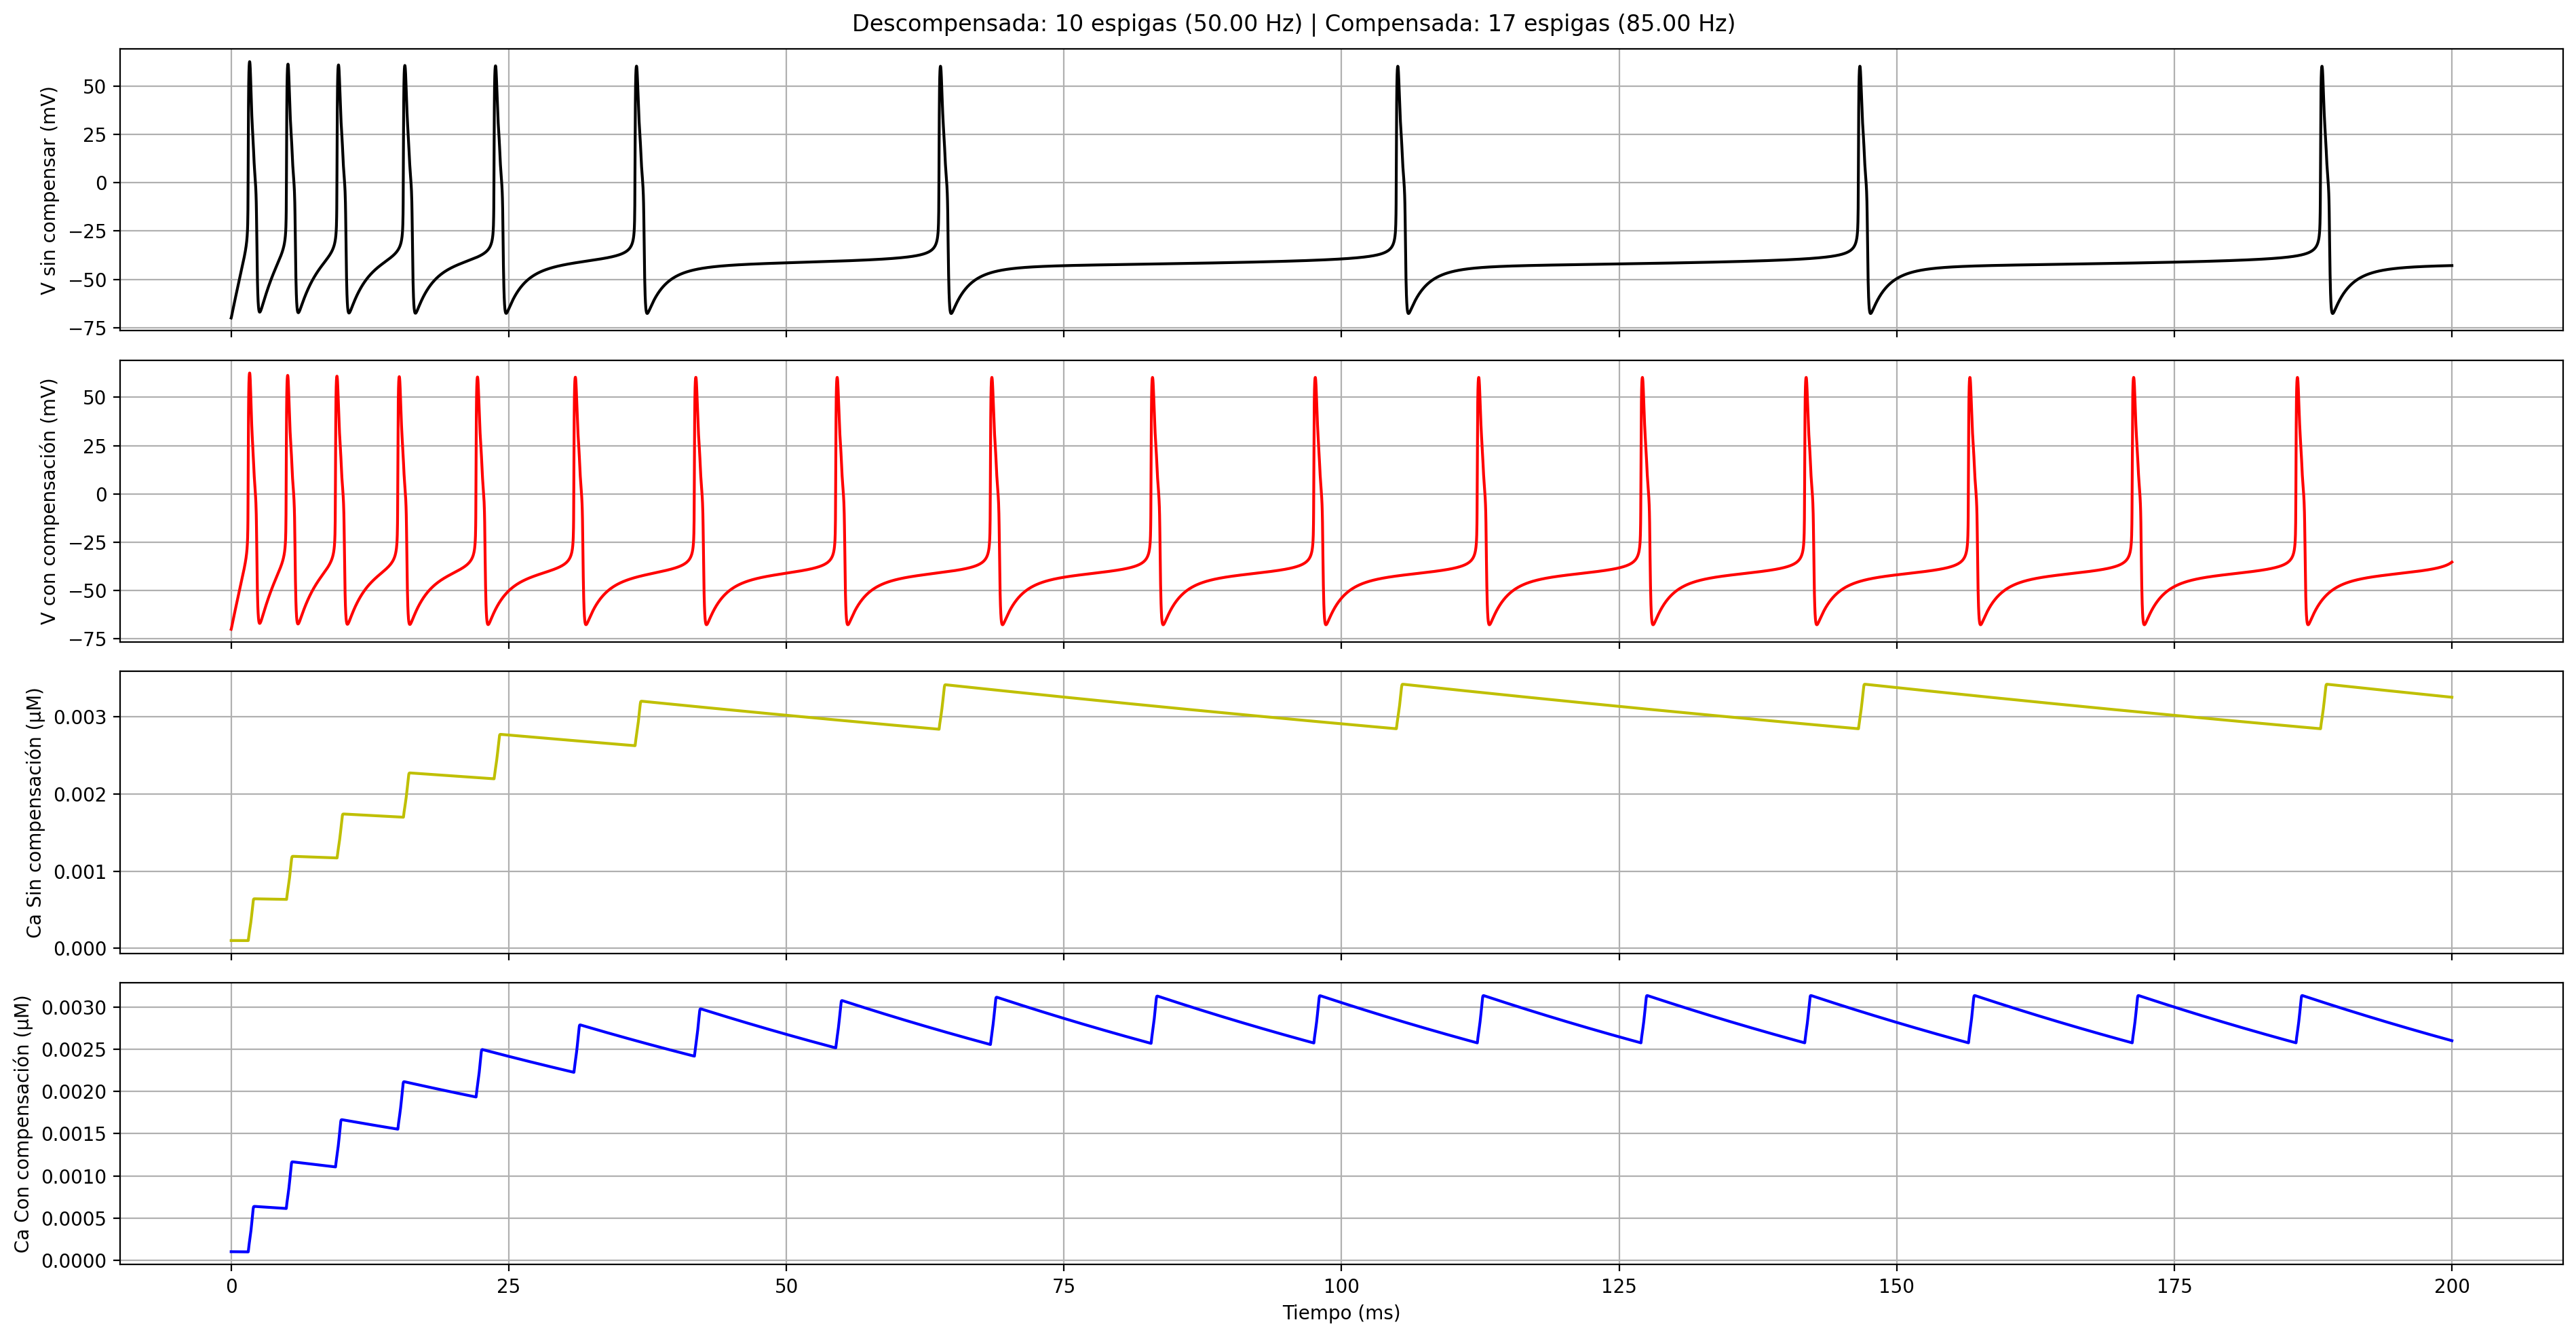

In [20]:
    # Simulaciones
   
    xx_old = simulateHH_numba(p_old, plot=False, seed=Semilla)
    xx_old1 = simulateHH_numba(p_old1, plot=False, seed=Semilla)

    # Conteo de espigas
    
    n_old, f_old, tiempos_old = contar_espigas(
        xx_old['sampTimes'],
        xx_old['v']
    )

    n_old1, f_old1, tiempos_old1 = contar_espigas(
        xx_old1['sampTimes'],
        xx_old1['v']
    )

    # GRÁFICA: solamente la simulación del valor actual

    fig, axs = plt.subplots(4, 1, figsize=(19, 10), sharex=True)

    axs[0].plot(
        xx_old['sampTimes'],
        xx_old['v'],
        label='sin compensación',
        color='k'
    )
    axs[0].set_ylabel('V sin compensar (mV)')
    axs[0].grid()

    axs[1].plot(
        xx_old1['sampTimes'],
        xx_old1['v'],
        label='Con compensación',
        color='r'
    )
    axs[1].set_ylabel('V con compensación (mV)')
    axs[1].grid()

    axs[2].plot(
        xx_old['sampTimes'],
        xx_old['c'],
        label='Sin compensación',
        color='y'
    )
    axs[2].set_ylabel('Ca Sin compensación (μM)')
    axs[2].grid()

    axs[3].plot(
        xx_old1['sampTimes'],
        xx_old1['c'],
        label='Con compensación',
        color='b'
    )
    axs[3].set_ylabel('Ca Con compensación (μM)')
    axs[3].set_xlabel('Tiempo (ms)')
    axs[3].grid()

    fig.suptitle(
        f'Descompensada: {n_old} espigas ({f_old:.2f} Hz) | '
        f'Compensada: {n_old1} espigas ({f_old1:.2f} Hz)'
    )

    plt.tight_layout()
    plt.show()

### - Para Kp

In [23]:
# Actualizamos parámetros para célula vieja y joven

p_old = copy.deepcopy(p)
p_old1 = copy.deepcopy(p)

Semilla = random.randint(1, 10000)

p_old['upStart']=0.0 # Inicio de la fase de despolarización del estímulo de la corriente
p_old['upStop']=0.01 # Fin de la fase de despolarización del estímulo de corriente
p_old['dnStart']=200.0 # Inicio de fase de repolarización del estímulo de corriente
p_old['dnStop']=200.01 # Fin de fase de repolarización del estímulo de corriente
p_old['rampAmp']=30.0 # Amplitud del estímulo de corriente
p_old['usePulseTrain'] = False # Activar tren de pulsos
p_old['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old['gSyn']= 0.2 # conductancia sináptica
p_old['gK']= 200.0 # Conductancia del potasio K+
p_old['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old['gNa']= 30.0 # Conductancia del sodio Na+
p_old['gCa']= 2.0 # Conductancia del calcio 
p_old['gL']= 0.01 # Conductancia de fuga 
p_old['Kp']= 8.0e-6  # Conversión de corriente de Ca en cambio de concentración intracelular

p_old1['upStart']=0.0 # Inicio de la fase de despolarización del estímulo de la corriente
p_old1['upStop']=0.01 # Fin de la fase de despolarización del estímulo de corriente
p_old1['dnStart']=200.0 # Inicio de fase de repolarización del estímulo de corriente
p_old1['dnStop']=200.01 # Fin de fase de repolarización del estímulo de corriente
p_old1['rampAmp']=30.0 # Amplitud del estímulo de corriente
p_old1['usePulseTrain'] = False # Activar tren de pulsos
p_old1['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old1['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old1['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old1['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old1['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old1['gSyn']= 0.2 # conductancia sináptica
p_old1['gK']= 200.0 # Conductancia del potasio K+
p_old1['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old1['gNa']= 30.0 # Conductancia del sodio Na+
p_old1['gCa']= 2.0 # Conductancia del calcio 
p_old1['gL']= 0.01 # Conductancia de fuga 
p_old1['Kp']= 4.3e-6  # Conversión de corriente de Ca en cambio de concentración intracelular

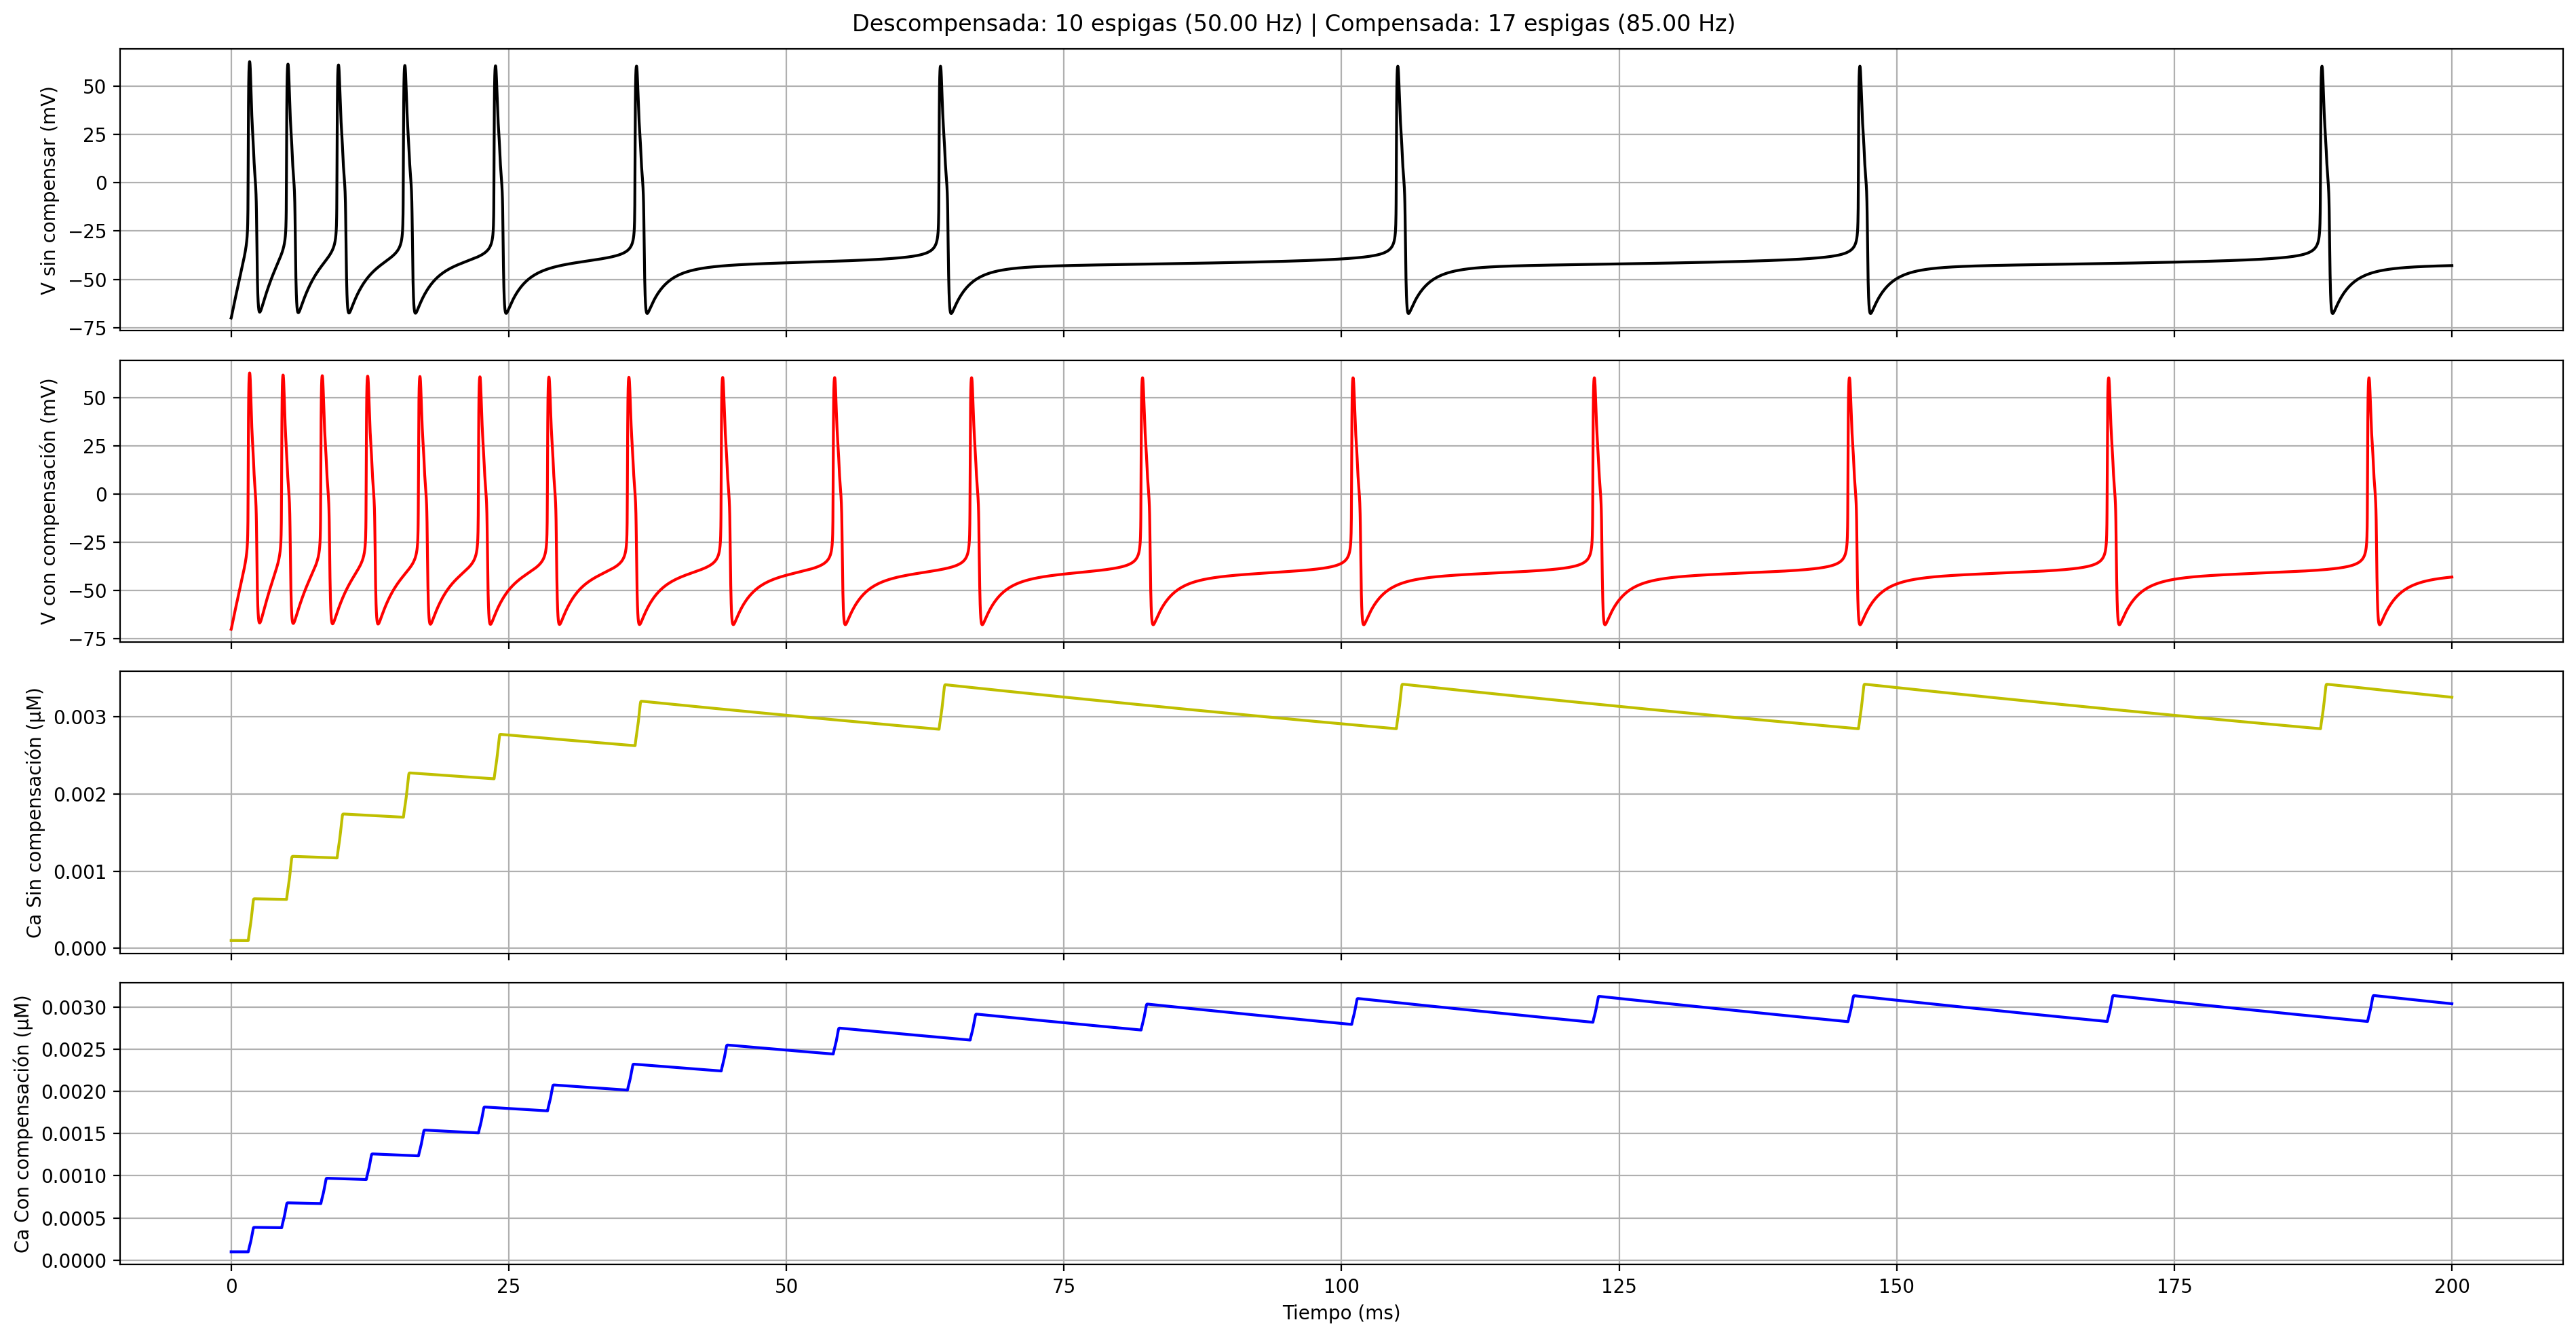

In [24]:
    # Simulaciones
   
    xx_old = simulateHH_numba(p_old, plot=False, seed=Semilla)
    xx_old1 = simulateHH_numba(p_old1, plot=False, seed=Semilla)

    # Conteo de espigas
    
    n_old, f_old, tiempos_old = contar_espigas(
        xx_old['sampTimes'],
        xx_old['v']
    )

    n_old1, f_old1, tiempos_old1 = contar_espigas(
        xx_old1['sampTimes'],
        xx_old1['v']
    )

    # GRÁFICA: solamente la simulación del valor actual

    fig, axs = plt.subplots(4, 1, figsize=(19, 10), sharex=True)

    axs[0].plot(
        xx_old['sampTimes'],
        xx_old['v'],
        label='sin compensación',
        color='k'
    )
    axs[0].set_ylabel('V sin compensar (mV)')
    axs[0].grid()

    axs[1].plot(
        xx_old1['sampTimes'],
        xx_old1['v'],
        label='Con compensación',
        color='r'
    )
    axs[1].set_ylabel('V con compensación (mV)')
    axs[1].grid()

    axs[2].plot(
        xx_old['sampTimes'],
        xx_old['c'],
        label='Sin compensación',
        color='y'
    )
    axs[2].set_ylabel('Ca Sin compensación (μM)')
    axs[2].grid()

    axs[3].plot(
        xx_old1['sampTimes'],
        xx_old1['c'],
        label='Con compensación',
        color='b'
    )
    axs[3].set_ylabel('Ca Con compensación (μM)')
    axs[3].set_xlabel('Tiempo (ms)')
    axs[3].grid()

    fig.suptitle(
        f'Descompensada: {n_old} espigas ({f_old:.2f} Hz) | '
        f'Compensada: {n_old1} espigas ({f_old1:.2f} Hz)'
    )

    plt.tight_layout()
    plt.show()